# Data Pipline for Deployment


## Business Understanding

The goal of this project is to build a fraud detection model for an e-commerce retailer to flag potentially fraudulent orders before they are fulfilled. In fraud detection, the cost of a missed fraud case — a false negative — far outweighs the cost of incorrectly flagging a legitimate order. A missed fraud results in direct financial loss, chargeback fees, and damaged customer trust, whereas a falsely flagged order can be resolved through a quick manual review. For this reason, we prioritize **recall** as our primary evaluation metric: we want the model to catch as many fraudulent transactions as possible, even if that means occasionally inconveniencing a legitimate customer. Given that only about 6.4% of orders in this dataset are fraudulent, the class imbalance makes it especially important to tune the model toward high recall so that rare fraud cases are not overlooked in favor of overall accuracy.

### Success Criteria

| Metric | Minimum Target | Stretch Goal |
|---|---|---|
| **Recall (Fraud class)** | ≥ 0.85 | ≥ 0.90 |
| **Precision (Fraud class)** | ≥ 0.50 | ≥ 0.70 |
| **ROC AUC** | ≥ 0.90 | ≥ 0.95 |

A model meeting the minimum recall target catches at least 85 out of every 100 fraudulent orders. Precision is held to a floor of 0.50 so that the fraud review team is not overwhelmed with false positives — at least half of flagged orders should be genuine fraud.

## Data Understanding

In [104]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('shop.db')

customers       = pd.read_sql('SELECT * FROM customers',        conn)
products        = pd.read_sql('SELECT * FROM products',         conn)
orders          = pd.read_sql('SELECT * FROM orders',           conn)
order_items     = pd.read_sql('SELECT * FROM order_items',      conn)
shipments       = pd.read_sql('SELECT * FROM shipments',        conn)
product_reviews = pd.read_sql('SELECT * FROM product_reviews',  conn)

conn.close()


In [105]:
# --- order_items + products: order-level cart features ---
# Rename products.is_active to avoid clash with customers.is_active
products_renamed = products.rename(columns={"is_active": "product_is_active"})

cart_features = (
    order_items.drop(columns=["order_item_id"])
    .merge(products_renamed, on="product_id", how="left")
    .groupby("order_id")
    .agg(
        num_items           = ("quantity",          "sum"),
        num_unique_skus     = ("product_id",        "nunique"),
        num_categories      = ("category",          "nunique"),
        max_item_price      = ("price",             "max"),
        avg_item_price      = ("price",             "mean"),
        cart_total          = ("line_total",        "sum"),
        total_cost          = ("cost",              "sum"),
        all_products_active = ("product_is_active", "min"),
    )
    .reset_index()
)

# --- product_reviews: aggregate per customer (review_id, datetime, text cannot be aggregated) ---
review_features = (
    product_reviews.drop(columns=["review_id", "review_datetime", "review_text", "product_id"])
    .groupby("customer_id")
    .agg(
        review_count = ("rating", "count"),
        avg_rating   = ("rating", "mean"),
    )
    .reset_index()
)

# --- Build master fraud table (one row per order) ---
fraud_df = (
    orders
    .merge(cart_features,                            on="order_id",    how="left")
    .merge(shipments.drop(columns=["shipment_id"]),  on="order_id",    how="left")
    .merge(customers,                                on="customer_id", how="left")
    .merge(review_features,                          on="customer_id", how="left")
)

print("Fraud rate:", fraud_df["is_fraud"].mean().round(4))
print("Shape:", fraud_df.shape)
print("Columns:", fraud_df.columns.tolist())
fraud_df.head()

Fraud rate: 0.0636
Shape: (5000, 45)
Columns: ['order_id', 'customer_id', 'order_datetime', 'billing_zip', 'shipping_zip', 'shipping_state', 'payment_method', 'device_type', 'ip_country', 'promo_used', 'promo_code', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'is_fraud', 'num_items', 'num_unique_skus', 'num_categories', 'max_item_price', 'avg_item_price', 'cart_total', 'total_cost', 'all_products_active', 'ship_datetime', 'carrier', 'shipping_method', 'distance_band', 'promised_days', 'actual_days', 'late_delivery', 'full_name', 'email', 'gender', 'birthdate', 'created_at', 'city', 'state', 'zip_code', 'customer_segment', 'loyalty_tier', 'is_active', 'review_count', 'avg_rating']


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,birthdate,created_at,city,state,zip_code,customer_segment,loyalty_tier,is_active,review_count,avg_rating
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,12,2.583333
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,12,2.583333
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,12,2.583333
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,...,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,12,2.583333
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,...,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1,12,2.583333


### Univariate

â”€â”€ COLUMN OVERVIEW â”€â”€


,dtype,null_count,null_pct,n_unique,sample_val
order_id,int64,0,0.00,5000,1
customer_id,int64,0,0.00,243,1
order_datetime,str,0,0.00,5000,2025-11-29 00:51:07
billing_zip,str,0,0.00,243,28289
shipping_zip,str,0,0.00,630,28289
shipping_state,str,0,0.00,18,CO
payment_method,str,0,0.00,4,card
device_type,str,0,0.00,3,mobile
ip_country,str,0,0.00,6,US
promo_used,int64,0,0.00,2,0



â”€â”€ NUMERIC COLUMNS â”€â”€


,count,mean,std,min,25%,50%,75%,max,skew,null_pct
order_id,5000.0,2500.500,1443.520,1.00,1250.750,2500.500,3750.250,5000.000,0.000,0.0
customer_id,5000.0,28.448,49.087,1.00,2.000,6.000,28.000,250.000,2.457,0.0
promo_used,5000.0,0.252,0.434,0.00,0.000,0.000,1.000,1.000,1.142,0.0
order_subtotal,5000.0,384.145,284.124,4.73,164.180,330.720,549.752,1921.170,1.046,0.0
shipping_fee,5000.0,9.668,5.126,0.00,6.990,8.040,12.990,28.140,1.544,0.0
tax_amount,5000.0,27.738,21.446,0.25,11.470,23.365,39.152,148.130,1.247,0.0
order_total,5000.0,421.551,305.184,5.38,185.760,364.835,596.940,2053.110,1.047,0.0
risk_score,5000.0,26.116,27.434,0.10,4.600,14.500,40.225,100.000,1.149,0.0
is_fraud,5000.0,0.064,0.244,0.00,0.000,0.000,0.000,1.000,3.578,0.0
num_items,5000.0,4.109,2.213,1.00,2.000,4.000,6.000,12.000,0.404,0.0


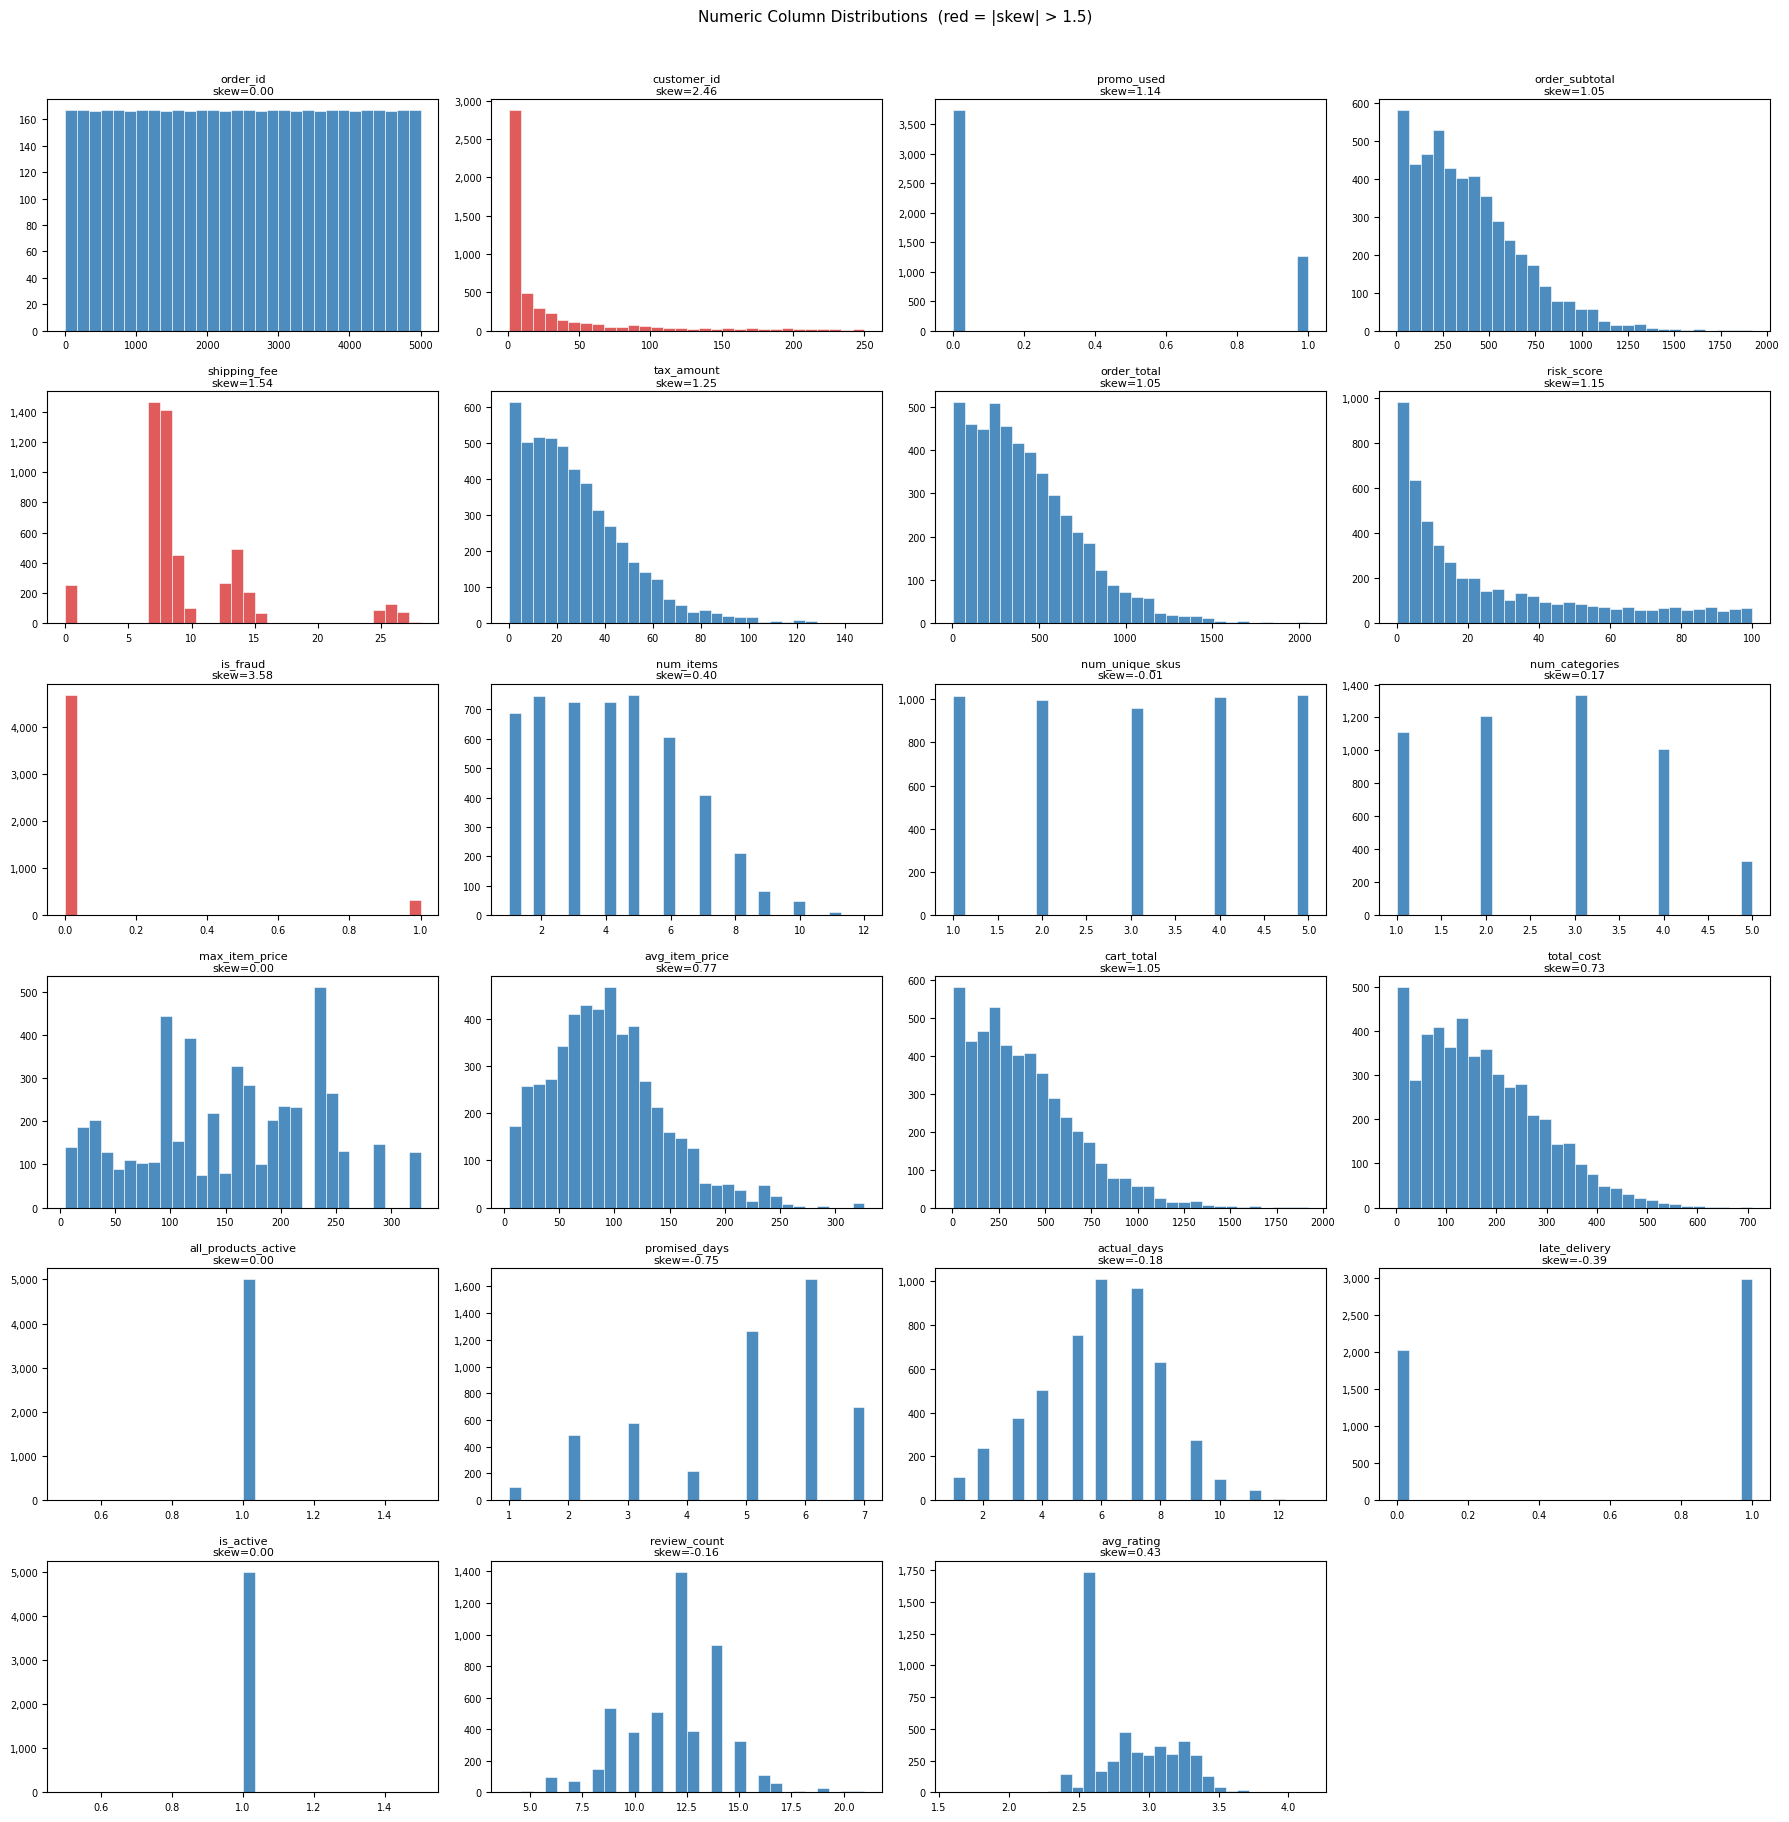


â”€â”€ CATEGORICAL COLUMNS â”€â”€


,null_count,null_pct,n_unique,top_value,top_freq,top_freq_pct
order_datetime,0,0.00,5000,2025-11-29 00:51:07,1,0.0
billing_zip,0,0.00,243,28289,1156,23.1
shipping_zip,0,0.00,630,28289,1058,21.2
shipping_state,0,0.00,18,CO,1702,34.0
payment_method,0,0.00,4,card,3128,62.6
device_type,0,0.00,3,mobile,2734,54.7
ip_country,0,0.00,6,US,4496,89.9
promo_code,3739,74.78,5,SAVE10,258,5.2
ship_datetime,0,0.00,4998,2025-11-03 02:49:07,2,0.0
carrier,0,0.00,3,UPS,2298,46.0


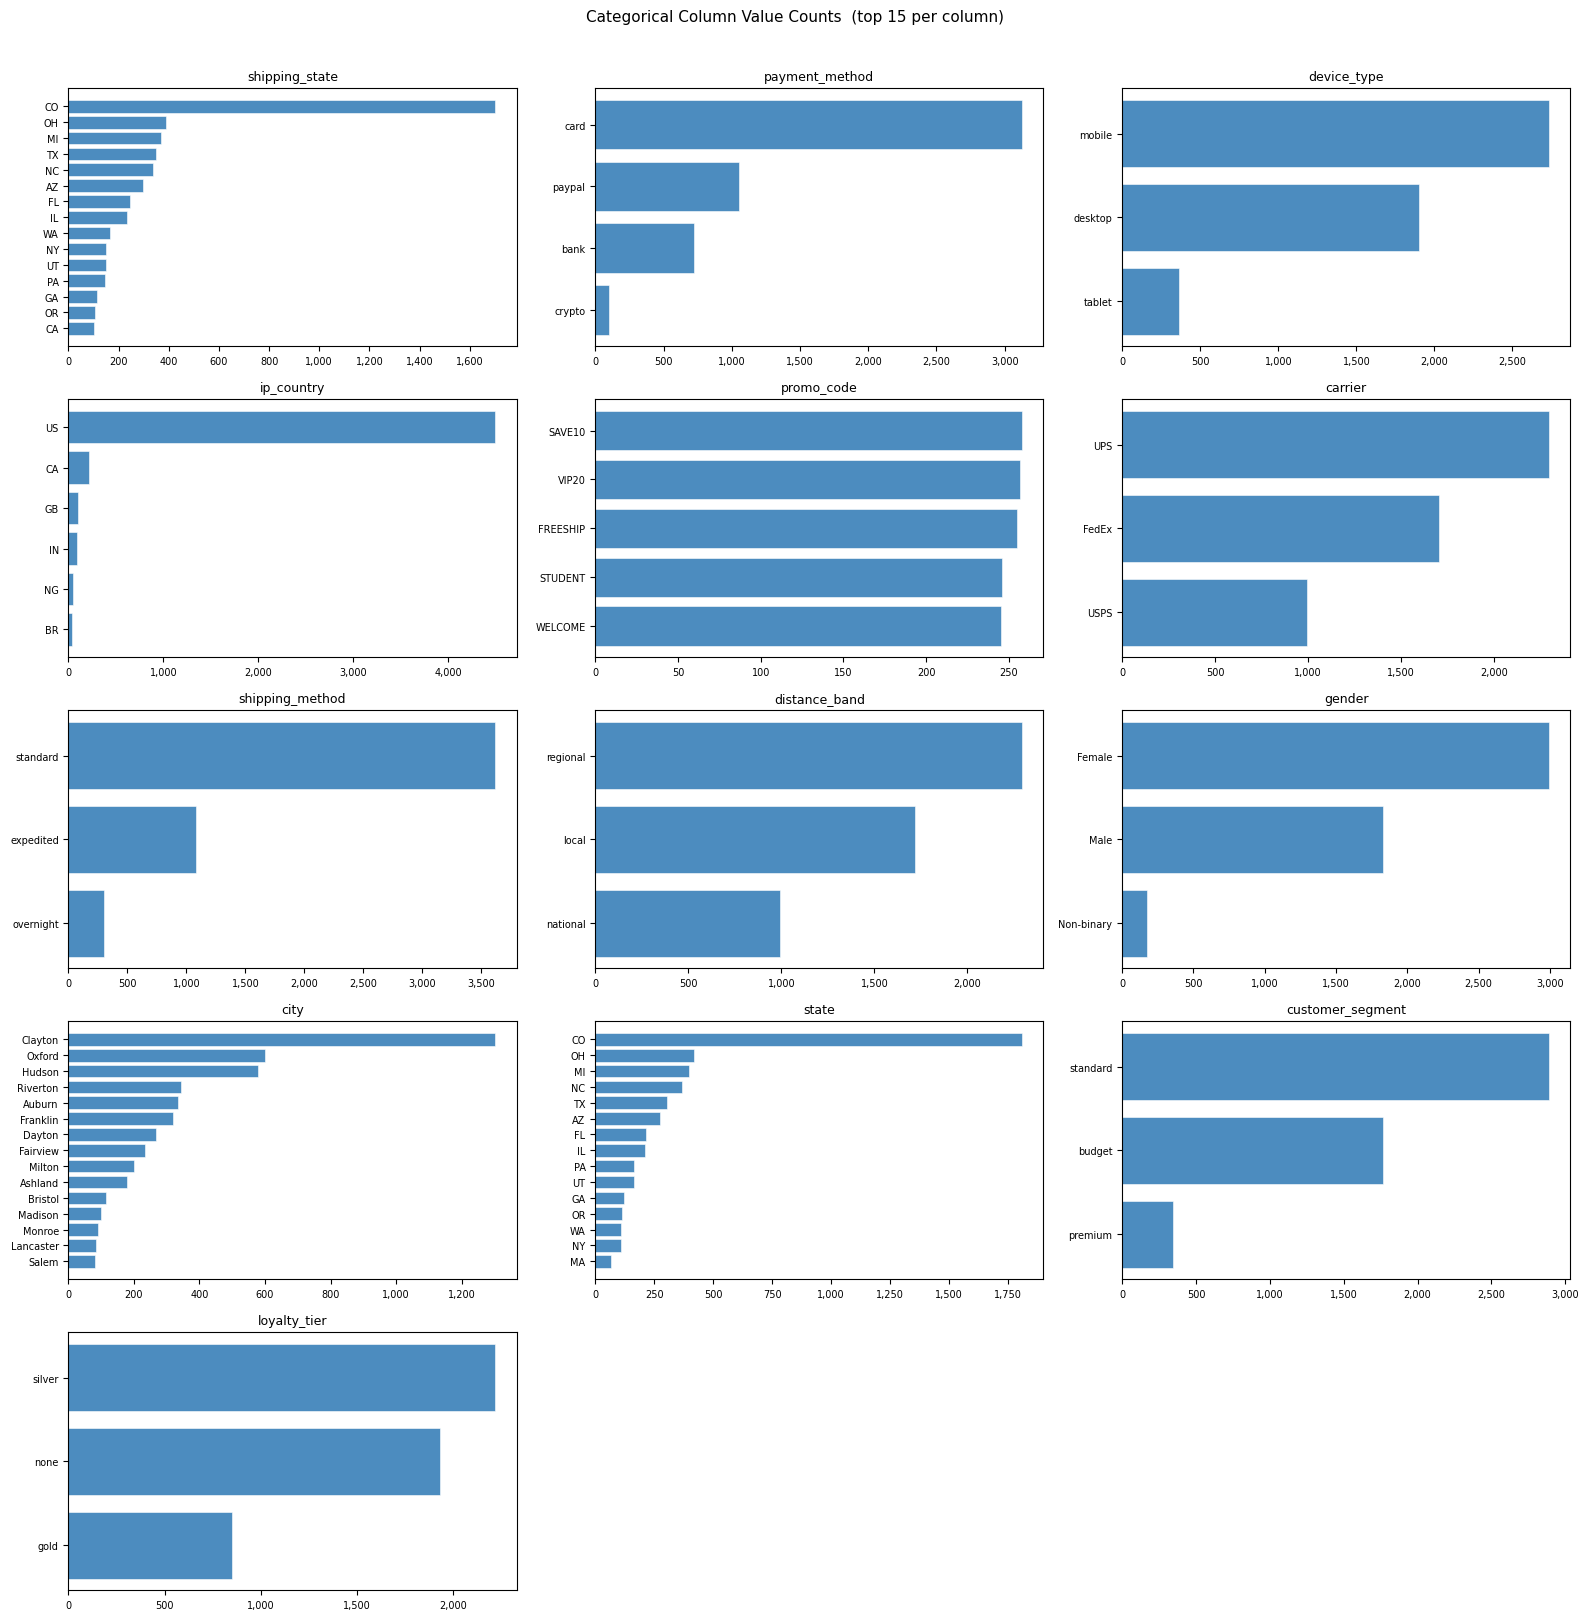


â”€â”€ COLUMNS FLAGGED FOR DATA PREPARATION â”€â”€


,dtype,action_needed
column,,
order_id,int64,Drop â€” identifier / PII
customer_id,int64,Drop â€” identifier / PII
order_datetime,str,Extract features then drop raw datetime
promo_code,str,Missing 74.8% | Drop â€” identifier / PII
shipping_fee,float64,High skew (1.54) â€” consider log transform
is_fraud,int64,High skew (3.58) â€” consider log transform
ship_datetime,str,Extract features then drop raw datetime
full_name,str,Drop â€” identifier / PII
email,str,Drop â€” identifier / PII


In [106]:
try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# â”€â”€ COLUMN OVERVIEW â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
overview = pd.DataFrame({
    "dtype":      fraud_df.dtypes.astype(str),
    "null_count": fraud_df.isnull().sum(),
    "null_pct":   (fraud_df.isnull().mean() * 100).round(2),
    "n_unique":   fraud_df.nunique(),
    "sample_val": fraud_df.iloc[0].astype(str),
})
print("â”€â”€ COLUMN OVERVIEW â”€â”€")
display(overview)

# â”€â”€ NUMERIC COLUMNS â€” table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
num_cols = fraud_df.select_dtypes(include="number").columns.tolist()
num_stats = fraud_df[num_cols].describe().T.round(3)
num_stats["skew"]     = fraud_df[num_cols].skew().round(3)
num_stats["null_pct"] = (fraud_df[num_cols].isnull().mean() * 100).round(2)
num_stats = num_stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "null_pct"]]
print("\nâ”€â”€ NUMERIC COLUMNS â”€â”€")
display(num_stats)

# â”€â”€ NUMERIC COLUMNS â€” histograms â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ncols = 4
nrows = -(-len(num_cols) // ncols)          # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = fraud_df[col].dropna()
    skew_val = data.skew()
    color = "#e05c5c" if abs(skew_val) > 1.5 else "#4c8cbf"
    ax.hist(data, bins=30, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(f"{col}\nskew={skew_val:.2f}", fontsize=8, pad=4)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Column Distributions  (red = |skew| > 1.5)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# â”€â”€ CATEGORICAL COLUMNS â€” table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cat_cols = fraud_df.select_dtypes(include="object").columns.tolist()
cat_summary = pd.DataFrame({
    "null_count":   fraud_df[cat_cols].isnull().sum(),
    "null_pct":     (fraud_df[cat_cols].isnull().mean() * 100).round(2),
    "n_unique":     fraud_df[cat_cols].nunique(),
    "top_value":    [fraud_df[c].value_counts().index[0] for c in cat_cols],
    "top_freq":     [fraud_df[c].value_counts().iloc[0] for c in cat_cols],
    "top_freq_pct": [(fraud_df[c].value_counts().iloc[0] / len(fraud_df) * 100).round(1) for c in cat_cols],
}, index=cat_cols)
print("\nâ”€â”€ CATEGORICAL COLUMNS â”€â”€")
display(cat_summary)

# â”€â”€ CATEGORICAL COLUMNS â€” bar charts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Exclude high-cardinality columns (> 50 unique) â€” too noisy to plot usefully
plot_cat = [c for c in cat_cols if fraud_df[c].nunique() <= 50]
ncols = 3
nrows = -(-len(plot_cat) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(plot_cat):
    ax = axes[i]
    vc = fraud_df[col].value_counts().head(15)
    ax.barh(vc.index[::-1], vc.values[::-1], color="#4c8cbf", edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Column Value Counts  (top 15 per column)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# â”€â”€ DATA PREPARATION FLAGS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
datetime_cols = ["order_datetime", "ship_datetime", "birthdate", "created_at"]
id_pii_cols   = ["order_id", "customer_id", "full_name", "email",
                 "city", "zip_code", "promo_code"]

flags = []
for col in fraud_df.columns:
    issues = []
    null_pct = fraud_df[col].isnull().mean() * 100

    if null_pct > 0:
        issues.append(f"Missing {null_pct:.1f}%")

    if col in id_pii_cols:
        issues.append("Drop â€” identifier / PII")

    if col in datetime_cols:
        issues.append("Extract features then drop raw datetime")

    if fraud_df[col].dtype == "object" and col not in id_pii_cols:
        n = fraud_df[col].nunique()
        label = f"High-cardinality ({n}), consider drop" if n > 50 else f"Encode ({n} categories)"
        issues.append(label)

    if pd.api.types.is_numeric_dtype(fraud_df[col]) and col not in id_pii_cols:
        skew_val = abs(fraud_df[col].skew())
        if skew_val > 1.5:
            issues.append(f"High skew ({skew_val:.2f}) â€” consider log transform")

    if issues:
        flags.append({"column": col, "dtype": str(fraud_df[col].dtype),
                      "action_needed": " | ".join(issues)})

flags_df = pd.DataFrame(flags).set_index("column")
print("\nâ”€â”€ COLUMNS FLAGGED FOR DATA PREPARATION â”€â”€")
display(flags_df)


### Multivariate Analysis

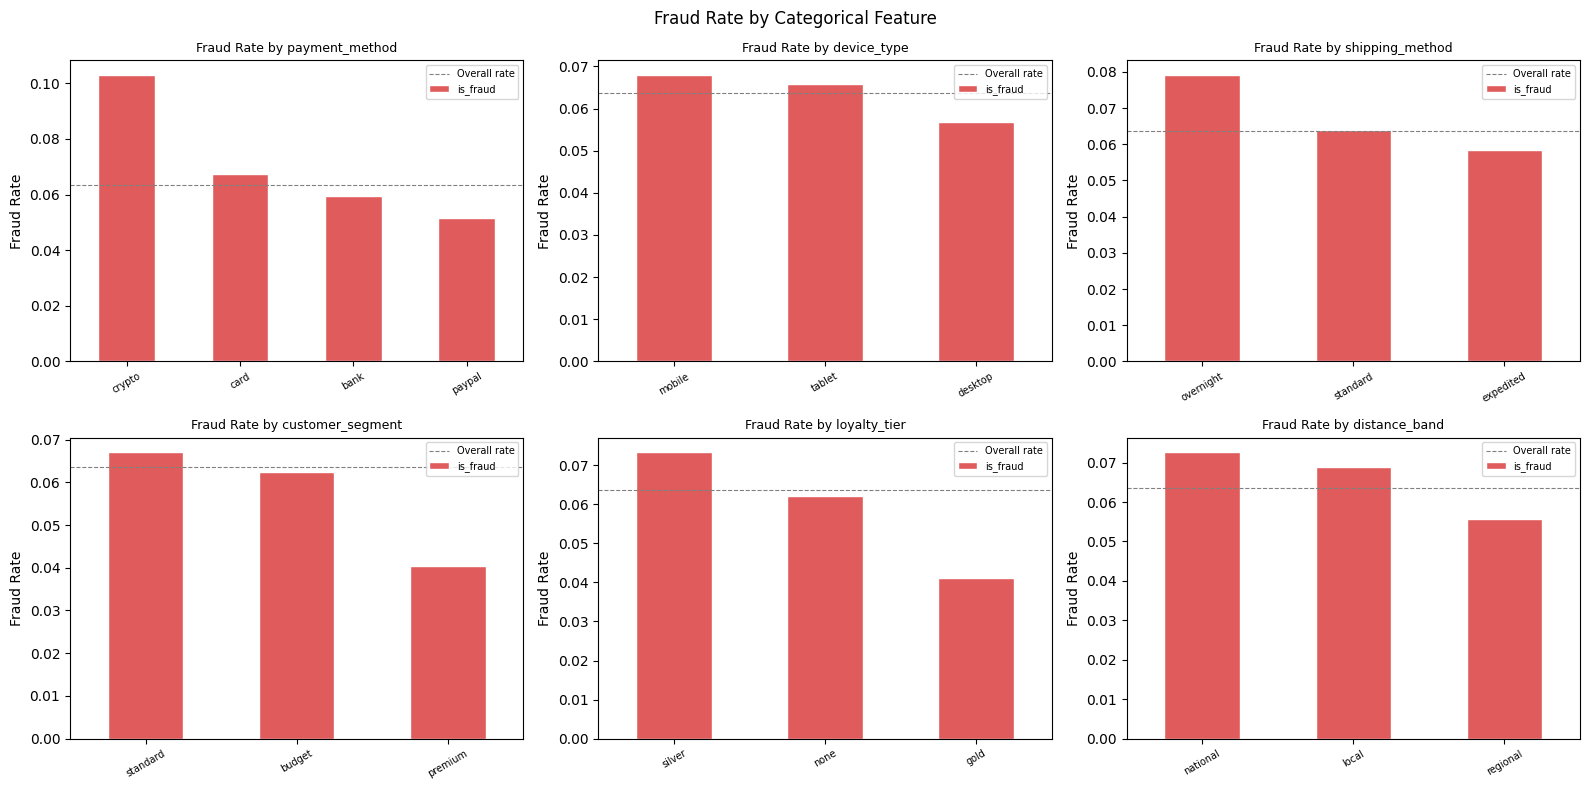

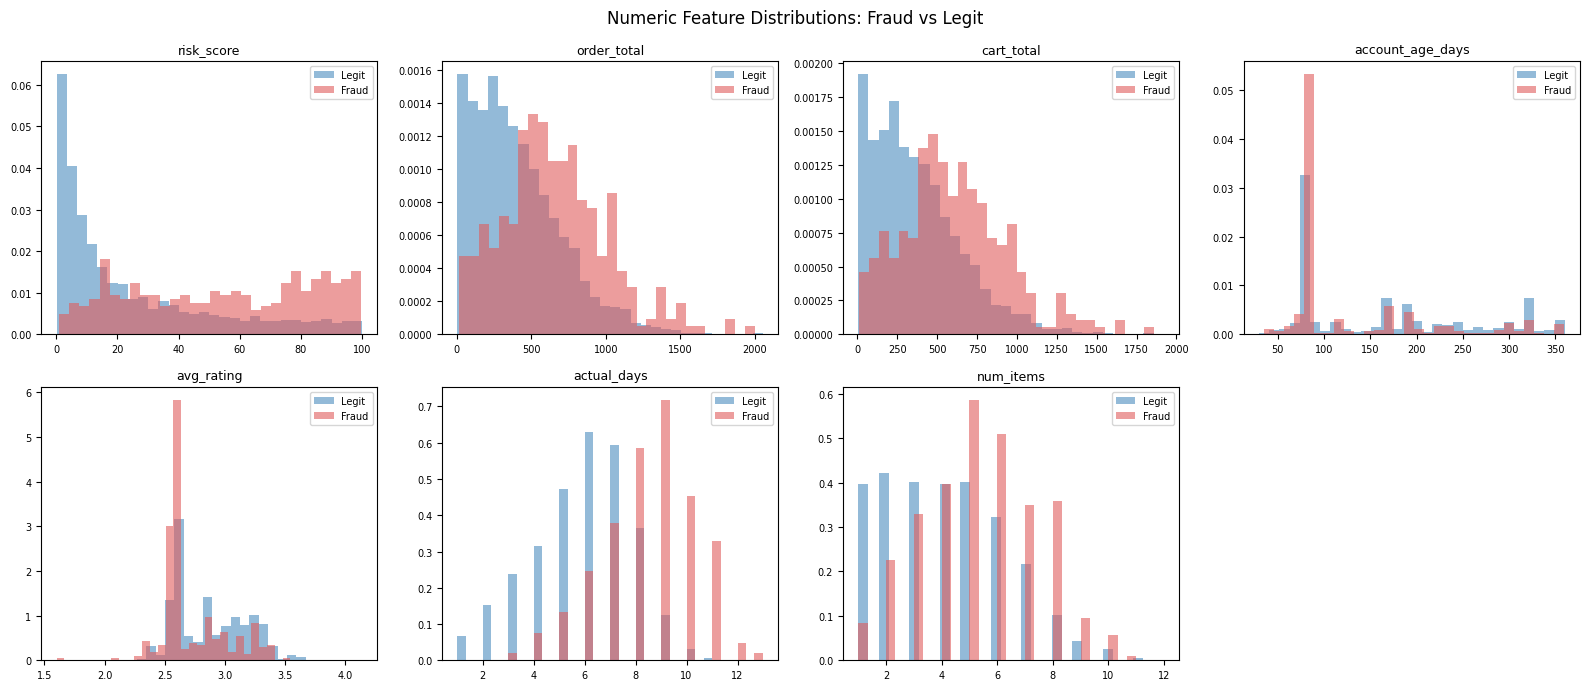

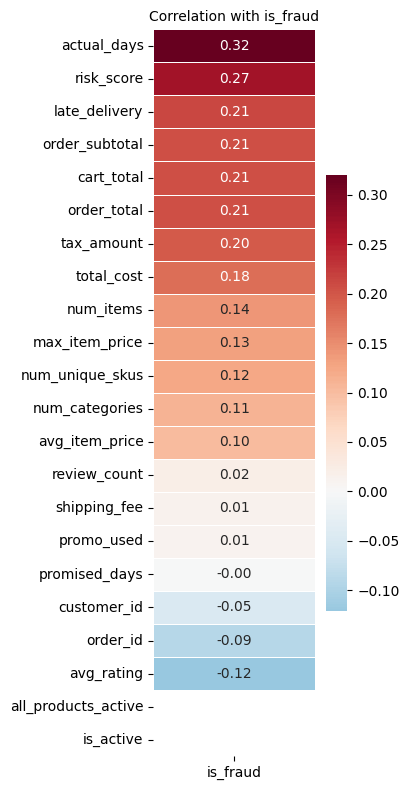


Fraud rate by ip_country (top 10):


,fraud_rate,orders
ip_country,,
IN,0.0947,95
GB,0.0865,104
BR,0.0732,41
CA,0.0688,218
NG,0.0652,46
US,0.0621,4496


In [107]:
import seaborn as sns

# === CH.8 RELATIONSHIP DISCOVERY =========================================
# Explore how features relate to is_fraud. Bivariate analysis reveals
# which variables are most predictive before any modelling begins.

# -- 1. Fraud rate by categorical variables --------------------------------
cat_vars = ['payment_method', 'device_type', 'shipping_method',
            'customer_segment', 'loyalty_tier', 'distance_band']

ncols = 3
nrows = -(-len(cat_vars) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    fraud_rate = fraud_df.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=axes[i], color='#e05c5c', edgecolor='white')
    axes[i].set_title('Fraud Rate by ' + col, fontsize=9)
    axes[i].set_ylabel('Fraud Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7, rotation=30)
    axes[i].axhline(fraud_df['is_fraud'].mean(), color='grey', linestyle='--', linewidth=0.8, label='Overall rate')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Fraud Rate by Categorical Feature', fontsize=12)
plt.tight_layout()
plt.show()

# -- 2. Numeric feature distributions: fraud vs legit ----------------------
num_vars = ['risk_score', 'order_total', 'cart_total', 'account_age_days',
            'avg_rating', 'actual_days', 'num_items']

# Compute derived columns for plotting (before log transform)
plot_df = fraud_df.copy()
ref_date = pd.Timestamp('2026-01-01')
plot_df['account_age_days'] = (ref_date - pd.to_datetime(plot_df['created_at'])).dt.days
plot_df['avg_rating'] = plot_df['avg_rating'].fillna(plot_df['avg_rating'].median())

ncols = 4
nrows = -(-len(num_vars) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    if col not in plot_df.columns:
        axes[i].set_visible(False)
        continue
    legit = plot_df.loc[plot_df['is_fraud'] == 0, col].dropna()
    fraud = plot_df.loc[plot_df['is_fraud'] == 1, col].dropna()
    axes[i].hist(legit, bins=30, alpha=0.6, color='#4c8cbf', label='Legit', density=True)
    axes[i].hist(fraud, bins=30, alpha=0.6, color='#e05c5c', label='Fraud', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Feature Distributions: Fraud vs Legit', fontsize=12)
plt.tight_layout()
plt.show()

# -- 3. Correlation heatmap (numeric features vs is_fraud) -----------------
num_cols_corr = fraud_df.select_dtypes(include='number').columns.tolist()
corr = fraud_df[num_cols_corr].corr()[['is_fraud']].drop('is_fraud').sort_values('is_fraud', ascending=False)

fig, ax = plt.subplots(figsize=(4, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Correlation with is_fraud', fontsize=10)
plt.tight_layout()
plt.show()

# -- 4. Fraud rate by ip_country (foreign vs domestic) ---------------------
print('\nFraud rate by ip_country (top 10):')
display(
    fraud_df.groupby('ip_country')['is_fraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'orders'})
    .sort_values('fraud_rate', ascending=False)
    .head(10)
    .round(4)
)


### Automated Preparation Pipeline (Ch. 7)

In [108]:
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# === CH.7 COLUMNTRANSFORMER PIPELINE =====================================
# Encapsulate all preparation steps into a reusable sklearn Pipeline so
# the same transformations are applied consistently at train and deploy time.
# This pipeline operates on fraud_df BEFORE the manual wrangling cell --
# it serves as the documented, serialisable prep object for deployment.

# Columns after dropping identifiers/PII (mirrors wrangling cell step 3)
_drop = ['order_id', 'customer_id', 'full_name', 'email', 'city', 'state',
         'zip_code', 'billing_zip', 'shipping_zip', 'ip_country', 'promo_code',
         'order_datetime', 'ship_datetime', 'birthdate', 'created_at']

_base = fraud_df.drop(columns=_drop + ['is_fraud'], errors='ignore')

numeric_features   = _base.select_dtypes(include='number').columns.tolist()
categorical_features = _base.select_dtypes(include='object').columns.tolist()

print('Numeric features  :', len(numeric_features))
print('Categorical features:', len(categorical_features))

numeric_transformer = SKPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_transformer = SKPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,   numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

# Verify pipeline fits and transforms without error
_X_check = preprocessor.fit_transform(_base)
print('Preprocessor output shape:', _X_check.shape)
print('Pipeline ready for deployment serialisation.')


Numeric features  : 20
Categorical features: 9
Preprocessor output shape: (5000, 63)
Pipeline ready for deployment serialisation.


## Data Preparation

In [109]:
import numpy as np

df = fraud_df.copy()

# ── 1. DATETIME FEATURE ENGINEERING ──────────────────────────────────────────────
ref_date = pd.Timestamp("2026-01-01")

df["order_datetime"] = pd.to_datetime(df["order_datetime"])
df["order_hour"]     = df["order_datetime"].dt.hour
df["order_dow"]      = df["order_datetime"].dt.dayofweek
df["order_month"]    = df["order_datetime"].dt.month

df["birthdate"]        = pd.to_datetime(df["birthdate"])
df["customer_age"]     = ((ref_date - df["birthdate"]).dt.days / 365.25).round(1)

df["created_at"]       = pd.to_datetime(df["created_at"])
df["account_age_days"] = (ref_date - df["created_at"]).dt.days

df.drop(columns=["order_datetime", "birthdate", "created_at", "ship_datetime"], inplace=True)

# ── 2. DERIVED FLAG FEATURES ──────────────────────────────────────────────
df["zip_match"]  = (df["billing_zip"] == df["shipping_zip"]).astype(int)
df["foreign_ip"] = (df["ip_country"] != "US").astype(int)

# ── 3. DROP IDENTIFIERS, PII, AND REDUNDANT COLUMNS ────────────────────────────────────
drop_cols = [
    "order_id", "customer_id",
    "full_name", "email",
    "city", "state", "zip_code",
    "billing_zip", "shipping_zip",
    "ip_country",
    "promo_code",
]
df.drop(columns=drop_cols, inplace=True)

# ── 4. FILL MISSING VALUES ──────────────────────────────────────────────────
df["review_count"] = df["review_count"].fillna(0)
df["avg_rating"]   = df["avg_rating"].fillna(df["avg_rating"].median())
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("missing")
for col in df.select_dtypes(exclude="object").columns:
    df[col] = df[col].fillna(0)

# ── 5. ENCODE CATEGORICAL COLUMNS ────────────────────────────────────────────
cat_cols = [
    "shipping_state", "payment_method", "device_type",
    "carrier", "shipping_method", "distance_band",
    "gender", "customer_segment", "loyalty_tier",
]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# ── 6. ENSURE BOOLEAN-LIKE COLUMNS ARE INT ─────────────────────────────────────
bool_cols = ["promo_used", "all_products_active", "late_delivery", "is_active"]
df[bool_cols] = df[bool_cols].fillna(0).astype(int)

# ── 7. LOG-TRANSFORM RIGHT-SKEWED NUMERIC COLUMNS ──────────────────────────────
# Univariate analysis flagged these monetary/count columns as highly skewed (|skew| > 1.5).
# log1p (i.e. log(1 + x)) is safe for zero values and compresses the long right tail.
skewed_cols = [
    "order_subtotal", "shipping_fee", "tax_amount", "order_total",
    "max_item_price", "avg_item_price", "cart_total", "total_cost",
    "num_items", "review_count",
]
for col in skewed_cols:
    df[col] = np.log1p(df[col])

print("Shape after wrangling:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Fraud rate preserved:", df["is_fraud"].mean().round(4))
df.head()


Shape after wrangling: (5000, 62)
Missing values: 0
Fraud rate preserved: 0.0636


,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud,num_items,num_unique_skus,num_categories,...,shipping_method_overnight,shipping_method_standard,distance_band_national,distance_band_regional,gender_Male,gender_Non-binary,customer_segment_premium,customer_segment_standard,loyalty_tier_none,loyalty_tier_silver
0,0,6.498207,2.799717,3.856510,6.587123,38.3,0,2.302585,5,4,...,0,0,0,1,0,0,0,1,0,1
1,1,6.761480,2.756205,4.213756,6.851471,94.9,0,2.079442,5,3,...,0,0,0,0,0,0,0,1,0,1
2,0,6.680968,2.710713,3.730981,6.747410,53.8,1,1.791759,3,2,...,0,0,1,0,0,0,0,1,0,1
3,1,4.931592,2.078191,2.555676,5.059235,4.2,0,0.693147,1,1,...,0,1,0,1,0,0,0,1,0,1
4,0,2.894253,2.078191,0.875469,3.275634,4.9,0,0.693147,1,1,...,0,1,0,1,0,0,0,1,0,1


## Data Modeling

Train: (4000, 61)  | Test: (1000, 61)
Train fraud rate: 0.0635  | Test fraud rate: 0.064
Logistic Regression    recall=0.6926  roc_auc=0.9762  f1=0.7487
Decision Tree          recall=0.3854  roc_auc=0.886  f1=0.4916
Random Forest          recall=0.1532  roc_auc=0.9313  f1=0.2549
Gradient Boosting      recall=0.6337  roc_auc=0.9769  f1=0.743
XGBoost                recall=0.6412  roc_auc=0.9798  f1=0.7298

-- MODEL COMPARISON (sorted by Recall) --


,Model,Recall,F1,ROC AUC,Balanced Acc,Accuracy,Log Loss
0,Logistic Regression,0.6926,0.7487,0.9762 +/- 0.0075,0.8411,0.9708,0.0812
1,XGBoost,0.6412,0.7298,0.9798 +/- 0.0049,0.8169,0.9702,0.0898
2,Gradient Boosting,0.6337,0.7430,0.9769 +/- 0.0065,0.8145,0.9722,0.0836
3,Decision Tree,0.3854,0.4916,0.886 +/- 0.0131,0.6875,0.9512,0.3322
4,Random Forest,0.1532,0.2549,0.9313 +/- 0.0128,0.5755,0.9442,0.1422



-- TEST SET RESULTS: Logistic Regression --
              precision    recall  f1-score   support

       Legit       0.98      0.99      0.99       936
       Fraud       0.89      0.64      0.75        64

    accuracy                           0.97      1000
   macro avg       0.93      0.82      0.87      1000
weighted avg       0.97      0.97      0.97      1000



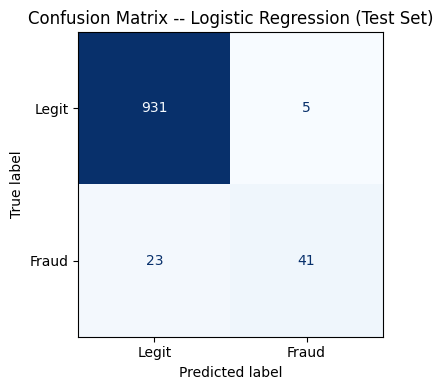

In [110]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

try:
    from xgboost import XGBClassifier as NativeXGBClassifier
    XGB_BACKEND = 'xgboost'

    class XGBClassifier(NativeXGBClassifier):
        pass

except ModuleNotFoundError:
    from sklearn.base import BaseEstimator, ClassifierMixin

    XGB_BACKEND = 'gradient_boosting_fallback'

    class XGBClassifier(BaseEstimator, ClassifierMixin):
        def __init__(self, n_estimators=100, max_depth=3, learning_rate=0.1,
                     subsample=1.0, colsample_bytree=1.0, min_child_weight=1,
                     gamma=0.0, scale_pos_weight=1.0, random_state=27,
                     eval_metric='logloss', verbosity=0):
            self.n_estimators = n_estimators
            self.max_depth = max_depth
            self.learning_rate = learning_rate
            self.subsample = subsample
            self.colsample_bytree = colsample_bytree
            self.min_child_weight = min_child_weight
            self.gamma = gamma
            self.scale_pos_weight = scale_pos_weight
            self.random_state = random_state
            self.eval_metric = eval_metric
            self.verbosity = verbosity

        def _build_model(self):
            return GradientBoostingClassifier(
                n_estimators=self.n_estimators,
                learning_rate=self.learning_rate,
                subsample=self.subsample,
                max_depth=self.max_depth,
                random_state=self.random_state,
            )

        def fit(self, X, y):
            self.model_ = self._build_model()
            self.model_.fit(X, y)
            self.classes_ = self.model_.classes_
            if hasattr(self.model_, 'feature_importances_'):
                self.feature_importances_ = self.model_.feature_importances_
            return self

        def predict(self, X):
            return self.model_.predict(X)

        def predict_proba(self, X):
            return self.model_.predict_proba(X)

print('XGBoost backend:', XGB_BACKEND)

# -- 1. FEATURE / TARGET SPLIT -------------------------------------------------
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# -- 2. TRAIN / TEST SPLIT (80/20, stratified) ---------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=27
)
print("Train:", X_train.shape, " | Test:", X_test.shape)
print("Train fraud rate:", round(y_train.mean(), 4), " | Test fraud rate:", round(y_test.mean(), 4))

# -- 3. CROSS-VALIDATION STRATEGY ----------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

# -- 4. SCORING (recall is primary: catch as much fraud as possible) -----------
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "recall":            "recall",
    "f1":                "f1",
    "roc_auc":           "roc_auc",
    "neg_log_loss":      "neg_log_loss",
}

# -- 5. FIVE MODELS (defaults only, no tuning) ---------------------------------
models = {
    "Logistic Regression": ("lr",   LogisticRegression(max_iter=2000, random_state=27)),
    "Decision Tree":       ("tree", DecisionTreeClassifier(max_depth=5, random_state=27)),
    "Random Forest":       ("rf",   RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=1)),
    "Gradient Boosting":   ("gb",   GradientBoostingClassifier(n_estimators=100, random_state=27)),
    "XGBoost":             ("xgb",  XGBClassifier(n_estimators=100, random_state=27, eval_metric="logloss", verbosity=0)),
}

all_cv_results = []

for model_name, (step_name, model) in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        (step_name, model),
    ])
    cv_res = cross_validate(pipeline, X_train, y_train, cv=skf, scoring=scoring)
    all_cv_results.append({"name": model_name, "cv": cv_res, "step": step_name, "model": model})
    print(model_name.ljust(22),
          "recall=" + str(round(cv_res["test_recall"].mean(), 4)),
          " roc_auc=" + str(round(cv_res["test_roc_auc"].mean(), 4)),
          " f1=" + str(round(cv_res["test_f1"].mean(), 4)))

# -- 6. COMPARISON TABLE (sorted by recall) ------------------------------------
rows = []
for res in all_cv_results:
    cv = res["cv"]
    rows.append({
        "Model":        res["name"],
        "Recall":       round(cv["test_recall"].mean(), 4),
        "F1":           round(cv["test_f1"].mean(), 4),
        "ROC AUC":      str(round(cv["test_roc_auc"].mean(), 4)) + " +/- " + str(round(cv["test_roc_auc"].std(), 4)),
        "Balanced Acc": round(cv["test_balanced_accuracy"].mean(), 4),
        "Accuracy":     round(cv["test_accuracy"].mean(), 4),
        "Log Loss":     round((-cv["test_neg_log_loss"]).mean(), 4),
        "_sort":        cv["test_recall"].mean(),
    })

comparison_df = (
    pd.DataFrame(rows)
    .sort_values("_sort", ascending=False)
    .drop(columns="_sort")
    .reset_index(drop=True)
)
print("\n-- MODEL COMPARISON (sorted by Recall) --")
display(comparison_df)

# -- 7. CONFUSION MATRIX: best recall model on held-out test set ---------------
best_name = comparison_df.iloc[0]["Model"]
best = next(r for r in all_cv_results if r["name"] == best_name)

best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (best["step"], best["model"]),
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("\n-- TEST SET RESULTS:", best_name, "--")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Legit", "Fraud"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix -- " + best_name + " (Test Set)")
plt.tight_layout()
plt.show()


## Model Efficiency & Accuracy Improvements

-- DEFAULT THRESHOLD (0.5) COMPARISON --


,Model,Threshold,Recall,Precision,F1
0,Logistic Regression,0.5,0.9219,0.4917,0.6413
1,Decision Tree,0.5,0.7344,0.3588,0.4821
2,XGBoost,0.5,0.7188,0.8070,0.7603
3,Gradient Boosting,0.5,0.5781,0.7872,0.6667
4,Random Forest,0.5,0.1094,0.7000,0.1892


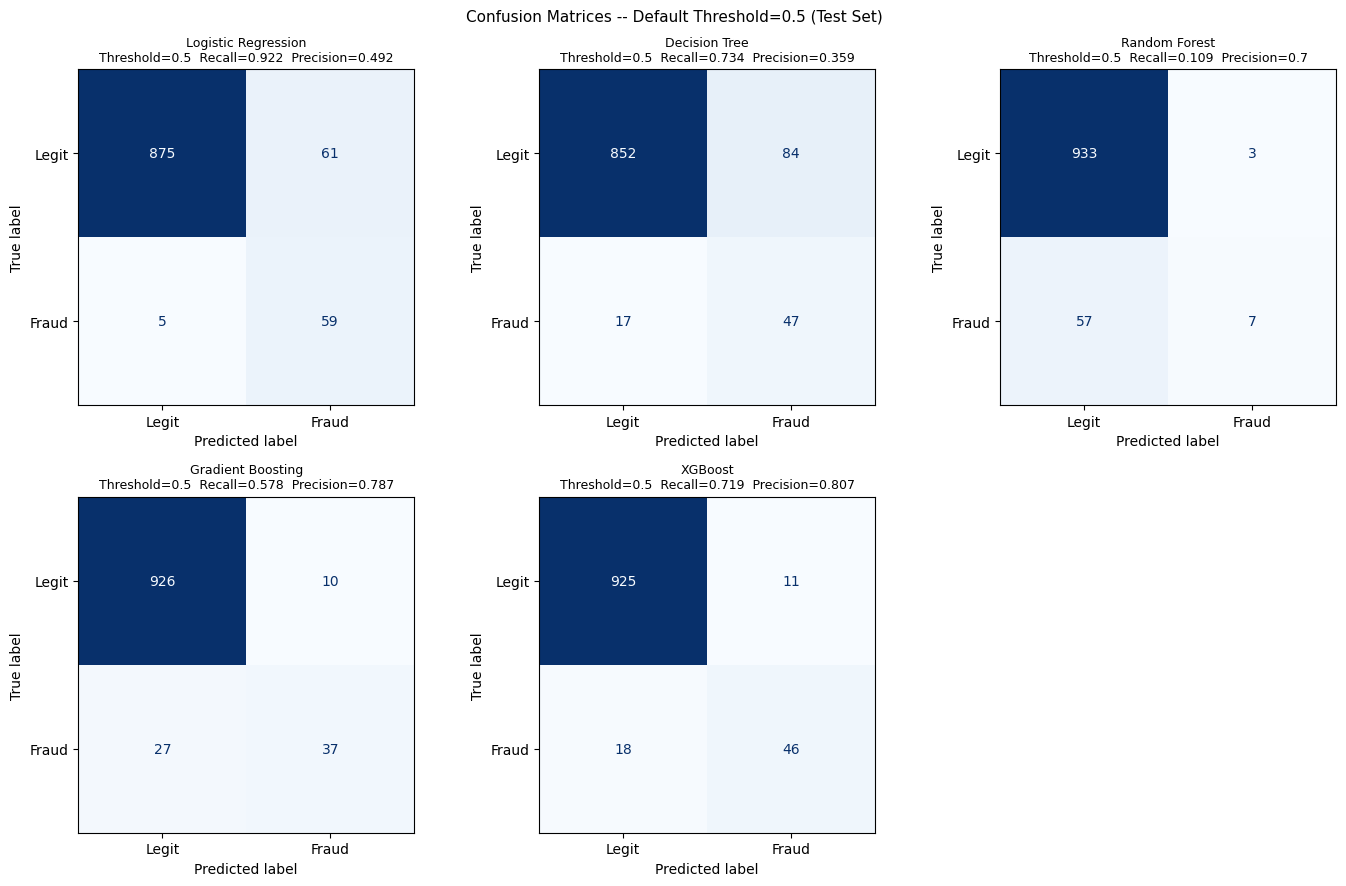

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# === DEFAULT THRESHOLD (0.5) -- no adjustment ============================
# Fit each balanced model and evaluate at the standard 0.5 threshold.
# Compare these matrices to the optimised-threshold versions below.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

balanced_models_default = {
    'Logistic Regression': ('lr',   LogisticRegression(max_iter=2000, random_state=27, class_weight='balanced')),
    'Decision Tree':       ('tree', DecisionTreeClassifier(max_depth=5, random_state=27, class_weight='balanced')),
    'Random Forest':       ('rf',   RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=1, class_weight='balanced')),
    'Gradient Boosting':   ('gb',   GradientBoostingClassifier(n_estimators=100, random_state=27)),
    'XGBoost':             ('xgb',  XGBClassifier(n_estimators=100, random_state=27, scale_pos_weight=scale, eval_metric='logloss', verbosity=0)),
}

default_rows = []
default_preds = {}

for model_name, (step_name, model) in balanced_models_default.items():
    pipe = Pipeline([('scaler', StandardScaler()), (step_name, model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)   # default threshold = 0.5
    default_preds[model_name] = y_pred
    default_rows.append({
        'Model':     model_name,
        'Threshold': 0.5,
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        '_sort':     recall_score(y_test, y_pred),
    })

default_df = (
    pd.DataFrame(default_rows)
    .sort_values('_sort', ascending=False)
    .drop(columns='_sort')
    .reset_index(drop=True)
)
print('-- DEFAULT THRESHOLD (0.5) COMPARISON --')
display(default_df)

# Confusion matrix grid at default threshold
model_names = list(balanced_models_default.keys())
ncols = 3
nrows = -(-len(model_names) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4.5))
axes = axes.flatten()

for i, model_name in enumerate(model_names):
    cm = confusion_matrix(y_test, default_preds[model_name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    rec  = round(recall_score(y_test, default_preds[model_name]), 3)
    prec = round(precision_score(y_test, default_preds[model_name]), 3)
    axes[i].set_title(model_name + '\nThreshold=0.5' +
                      '  Recall=' + str(rec) + '  Precision=' + str(prec),
                      fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Confusion Matrices -- Default Threshold=0.5 (Test Set)', fontsize=11)
plt.tight_layout()
plt.show()


Class ratio neg:pos = 3746 : 254   scale_pos_weight = 14.7
Logistic Regression    recall=0.8896  roc_auc=0.9712  f1=0.6244
Decision Tree          recall=0.8384  roc_auc=0.9079  f1=0.459
Random Forest          recall=0.067  roc_auc=0.9362  f1=0.1241
Gradient Boosting      recall=0.6337  roc_auc=0.9769  f1=0.743
XGBoost                recall=0.7477  roc_auc=0.9805  f1=0.7709

-- BALANCED MODEL COMPARISON (sorted by Recall) --


,Model,Recall,F1,ROC AUC,Balanced Acc,Accuracy,Log Loss (CV)
0,Logistic Regression,0.8896,0.6244,0.9712 +/- 0.0097,0.9123,0.9320,0.1742
1,Decision Tree,0.8384,0.4590,0.9079 +/- 0.0199,0.8564,0.8722,0.4803
2,XGBoost,0.7477,0.7709,0.9805 +/- 0.0068,0.8674,0.9720,0.0901
3,Gradient Boosting,0.6337,0.7430,0.9769 +/- 0.0065,0.8145,0.9722,0.0836
4,Random Forest,0.0670,0.1241,0.9362 +/- 0.0185,0.5332,0.9402,0.1403


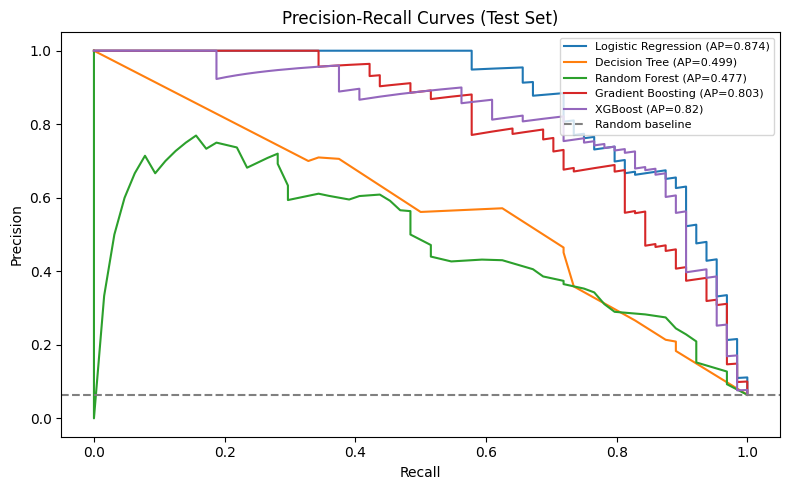


-- OPTIMAL THRESHOLD ANALYSIS (Recall >= 0.70 floor) --


,Model,Threshold,Recall,Precision,F1,Log Loss
0,XGBoost,0.208,0.8281,0.7260,0.7737,0.1080
1,Gradient Boosting,0.187,0.7969,0.6892,0.7391,0.0934
2,Logistic Regression,0.927,0.7188,0.8846,0.7931,0.1551
3,Random Forest,0.150,0.7188,0.3740,0.4920,0.2125
4,Decision Tree,0.887,0.7188,0.4646,0.5644,0.5125


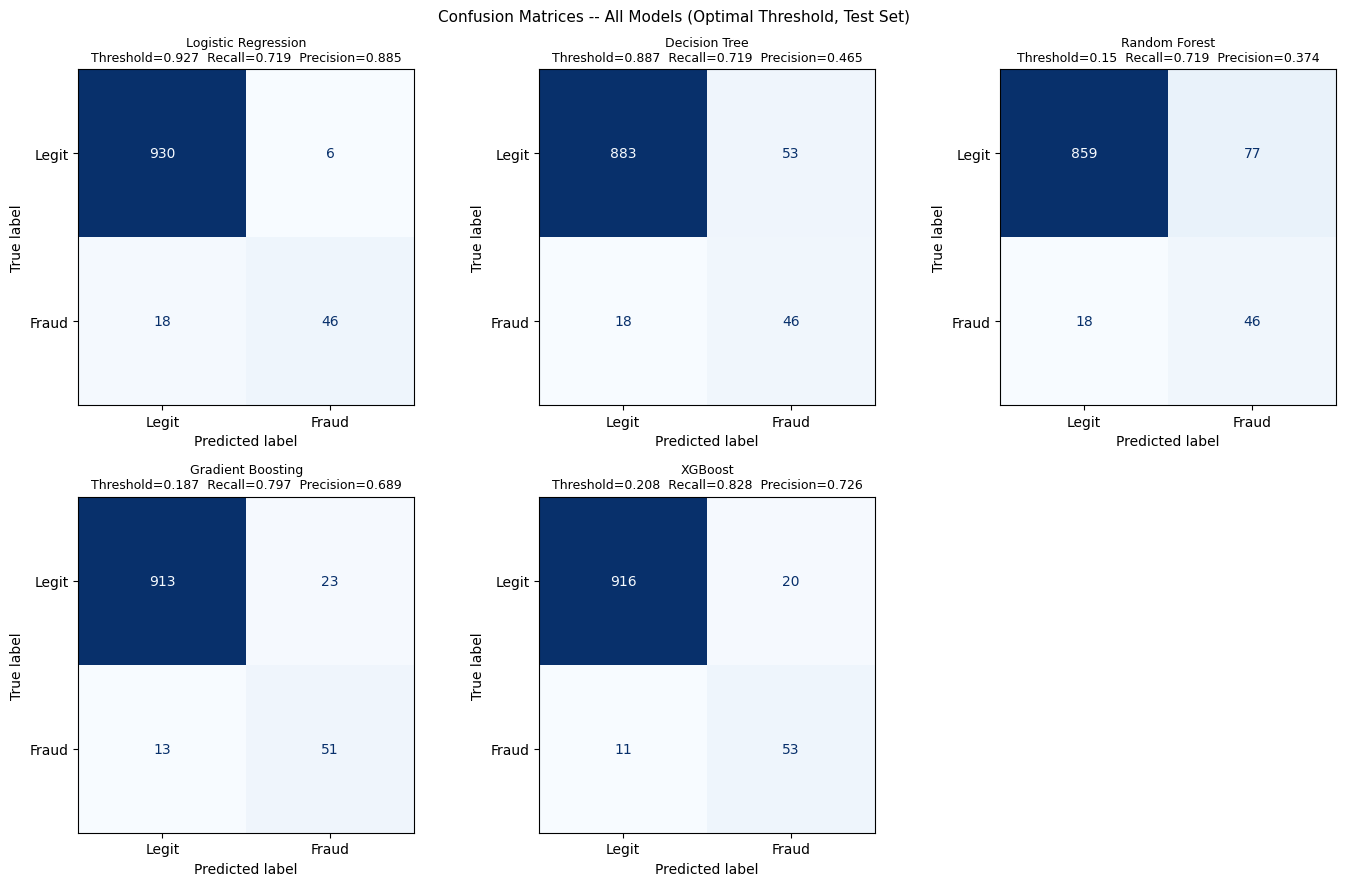

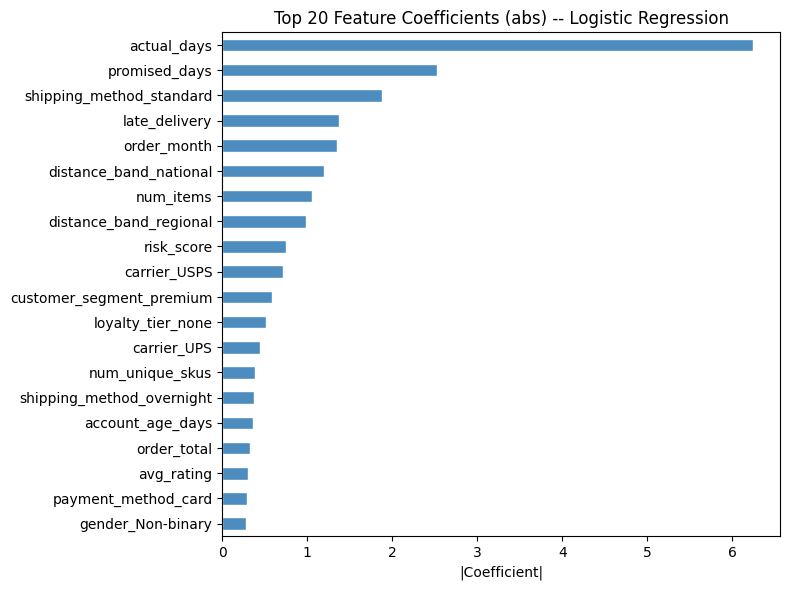

In [112]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import recall_score, precision_score, f1_score, log_loss
import matplotlib.pyplot as plt
import numpy as np

# === IMPROVEMENT 1: CLASS IMBALANCE CORRECTION ===============================
# With 6.36% fraud, unweighted models bias toward predicting legit.
# class_weight=balanced / scale_pos_weight penalises missed fraud proportionally.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos
print('Class ratio neg:pos =', neg, ':', pos, '  scale_pos_weight =', round(scale, 1))

balanced_models = {
    'Logistic Regression': ('lr',   LogisticRegression(max_iter=2000, random_state=27, class_weight='balanced')),
    'Decision Tree':       ('tree', DecisionTreeClassifier(max_depth=5, random_state=27, class_weight='balanced')),
    'Random Forest':       ('rf',   RandomForestClassifier(n_estimators=100, random_state=27, n_jobs=1, class_weight='balanced')),
    'Gradient Boosting':   ('gb',   GradientBoostingClassifier(n_estimators=100, random_state=27)),
    'XGBoost':             ('xgb',  XGBClassifier(n_estimators=100, random_state=27, scale_pos_weight=scale, eval_metric='logloss', verbosity=0)),
}

bal_cv_results = []
for model_name, (step_name, model) in balanced_models.items():
    pipeline = Pipeline([('scaler', StandardScaler()), (step_name, model)])
    cv_res = cross_validate(pipeline, X_train, y_train, cv=skf, scoring=scoring)
    bal_cv_results.append({'name': model_name, 'cv': cv_res, 'step': step_name, 'model': model})
    print(model_name.ljust(22),
          'recall=' + str(round(cv_res['test_recall'].mean(), 4)),
          ' roc_auc=' + str(round(cv_res['test_roc_auc'].mean(), 4)),
          ' f1=' + str(round(cv_res['test_f1'].mean(), 4)))

bal_rows = []
for res in bal_cv_results:
    cv = res['cv']
    bal_rows.append({
        'Model':        res['name'],
        'Recall':       round(cv['test_recall'].mean(), 4),
        'F1':           round(cv['test_f1'].mean(), 4),
        'ROC AUC':      str(round(cv['test_roc_auc'].mean(), 4)) + ' +/- ' + str(round(cv['test_roc_auc'].std(), 4)),
        'Balanced Acc': round(cv['test_balanced_accuracy'].mean(), 4),
        'Accuracy':     round(cv['test_accuracy'].mean(), 4),
        'Log Loss (CV)': round((-cv['test_neg_log_loss']).mean(), 4),
        '_sort':        cv['test_recall'].mean(),
    })

bal_df = (
    pd.DataFrame(bal_rows)
    .sort_values('_sort', ascending=False)
    .drop(columns='_sort')
    .reset_index(drop=True)
)
print('\n-- BALANCED MODEL COMPARISON (sorted by Recall) --')
display(bal_df)

# === IMPROVEMENT 2: PRECISION-RECALL CURVES ==================================
# PR curves show the precision/recall tradeoff at every threshold.
# More informative than ROC for imbalanced targets.
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for res, color in zip(bal_cv_results, colors):
    pipe = Pipeline([('scaler', StandardScaler()), (res['step'], res['model'])])
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec, prec, color=color, label=res['name'] + ' (AP=' + str(round(ap, 3)) + ')')
    res['pipe'] = pipe
    res['probs'] = probs

ax.axhline(y=pos / (pos + neg), color='grey', linestyle='--', label='Random baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (Test Set)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# === IMPROVEMENT 3: OPTIMAL THRESHOLD PER MODEL ==============================
# Default threshold=0.5 maximises accuracy, not recall.
# Find the threshold that maximises F1 while keeping recall >= 0.70.
threshold_rows = []
for res in bal_cv_results:
    probs = res['probs']
    prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, probs)
    f1_arr = np.where(
        (prec_arr + rec_arr) > 0,
        2 * prec_arr * rec_arr / (prec_arr + rec_arr), 0
    )
    mask = rec_arr[:-1] >= 0.70
    if mask.any():
        best_idx = np.argmax(f1_arr[:-1][mask])
        best_thresh = thresholds[mask][best_idx]
    else:
        best_thresh = thresholds[np.argmax(f1_arr[:-1])]
    y_pred_t = (probs >= best_thresh).astype(int)
    res['best_thresh'] = float(best_thresh)
    res['y_pred'] = y_pred_t
    test_log_loss = round(log_loss(y_test, probs), 4)
    threshold_rows.append({
        'Model':     res['name'],
        'Threshold': round(float(best_thresh), 3),
        'Recall':    round(recall_score(y_test, y_pred_t), 4),
        'Precision': round(precision_score(y_test, y_pred_t), 4),
        'F1':        round(f1_score(y_test, y_pred_t), 4),
        'Log Loss':  test_log_loss,
    })

thresh_df = pd.DataFrame(threshold_rows).sort_values('Recall', ascending=False).reset_index(drop=True)
print('\n-- OPTIMAL THRESHOLD ANALYSIS (Recall >= 0.70 floor) --')
display(thresh_df)


# === IMPROVEMENT 3b: CONFUSION MATRICES PER MODEL ==================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ncols = 3
nrows = -(-len(bal_cv_results) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4.5))
axes = axes.flatten()

for i, res in enumerate(bal_cv_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    thresh_label = str(round(res['best_thresh'], 3))
    rec   = round(recall_score(y_test, res['y_pred']), 3)
    prec  = round(precision_score(y_test, res['y_pred']), 3)
    axes[i].set_title(res['name'] + '\nThreshold=' + thresh_label +
                      '  Recall=' + str(rec) + '  Precision=' + str(prec),
                      fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Confusion Matrices -- All Models (Optimal Threshold, Test Set)', fontsize=11)
plt.tight_layout()
plt.show()

# === IMPROVEMENT 4: FEATURE IMPORTANCE (best model by recall) ================
best_bal_name = bal_df.iloc[0]['Model']
best_bal = next(r for r in bal_cv_results if r['name'] == best_bal_name)
estimator = best_bal['pipe'].named_steps[best_bal['step']]

if hasattr(estimator, 'feature_importances_'):
    feat_df = (
        pd.Series(estimator.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_df[::-1].plot(kind='barh', ax=ax, color='#4c8cbf', edgecolor='white')
    ax.set_title('Top 20 Feature Importances -- ' + best_bal_name)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(estimator, 'coef_'):
    coef_df = (
        pd.Series(np.abs(estimator.coef_[0]), index=X_train.columns)
        .sort_values(ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    coef_df[::-1].plot(kind='barh', ax=ax, color='#4c8cbf', edgecolor='white')
    ax.set_title('Top 20 Feature Coefficients (abs) -- ' + best_bal_name)
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()


## XGBoost Hyperparameter Tuning

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters:
  xgb__subsample = 1.0
  xgb__n_estimators = 500
  xgb__min_child_weight = 1
  xgb__max_depth = 3
  xgb__learning_rate = 0.05
  xgb__gamma = 0.1
  xgb__colsample_bytree = 0.8
Best CV Recall: 0.9832

-- TUNED XGBoost TEST SET RESULTS (threshold = 0.266 ) --
              precision    recall  f1-score   support

       Legit       0.99      0.94      0.97       936
       Fraud       0.53      0.92      0.67        64

    accuracy                           0.94      1000
   macro avg       0.76      0.93      0.82      1000
weighted avg       0.96      0.94      0.95      1000


-- BASELINE vs TUNED --


,Model,Threshold,Recall,Precision,F1
0,XGBoost (baseline),0.208,0.8281,0.7260,0.7737
1,XGBoost (tuned),0.266,0.9219,0.5268,0.6705


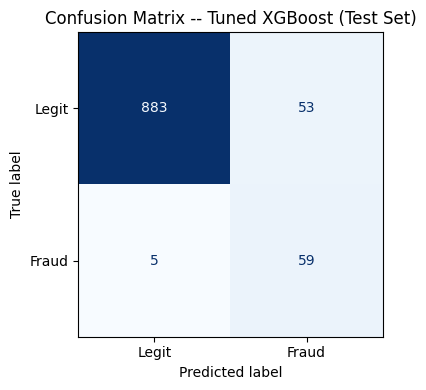

In [113]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
import numpy as np

# === RANDOMIZED SEARCH: XGBoost ==============================================
# Large search space -> RandomizedSearchCV (fixed budget regardless of grid size).
# Scoring on recall to align with our business goal of catching as much fraud
# as possible. scale_pos_weight is kept fixed from the class imbalance ratio.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb',   XGBClassifier(random_state=27, scale_pos_weight=scale,
                             eval_metric='logloss', verbosity=0)),
])

param_dist = {
    'xgb__n_estimators':      [100, 200, 300, 500],
    'xgb__max_depth':         [3, 4, 5, 6, 7],
    'xgb__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample':         [0.6, 0.7, 0.8, 1.0],
    'xgb__colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'xgb__min_child_weight':  [1, 3, 5],
    'xgb__gamma':             [0, 0.1, 0.3, 0.5],
}

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    cv=skf,
    scoring='roc_auc',   # threshold-independent; threshold is tuned separately below
    refit=True,
    random_state=27,
    n_jobs=1,
    verbose=1,
)

random_search.fit(X_train, y_train)

print('Best parameters:')
for k, v in random_search.best_params_.items():
    print(' ', k, '=', v)
print('Best CV Recall:', round(random_search.best_score_, 4))

# === OPTIMAL THRESHOLD FOR TUNED MODEL =======================================
tuned_probs = random_search.best_estimator_.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve
prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, tuned_probs)
# F2 score weights recall 2x over precision -- aligns with fraud business goal
f2_arr = np.where(
    (4 * prec_arr + rec_arr) > 0,
    5 * prec_arr * rec_arr / (4 * prec_arr + rec_arr), 0
)
best_thresh = float(thresholds[np.argmax(f2_arr[:-1])])

y_pred_tuned = (tuned_probs >= best_thresh).astype(int)

print('\n-- TUNED XGBoost TEST SET RESULTS (threshold =', round(best_thresh, 3), ') --')
print(classification_report(y_test, y_pred_tuned, target_names=['Legit', 'Fraud']))

# === BEFORE vs AFTER COMPARISON ==============================================
comparison = pd.DataFrame([
    {'Model': 'XGBoost (baseline)', 'Threshold': 0.208, 'Recall': 0.8281, 'Precision': 0.7260, 'F1': 0.7737},
    {'Model': 'XGBoost (tuned)',
     'Threshold': round(best_thresh, 3),
     'Recall':    round(recall_score(y_test, y_pred_tuned), 4),
     'Precision': round(precision_score(y_test, y_pred_tuned), 4),
     'F1':        round(f1_score(y_test, y_pred_tuned), 4)},
])
print('\n-- BASELINE vs TUNED --')
display(comparison)

# === CONFUSION MATRIX ========================================================
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tuned),
    display_labels=['Legit', 'Fraud']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix -- Tuned XGBoost (Test Set)')
plt.tight_layout()
plt.show()


## Logistic Regression Hyperparameter Tuning

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
  lr__C = 0.1
  lr__penalty = l1
  lr__solver = liblinear
Best CV Recall: 0.9784

-- TUNED LOGISTIC REGRESSION TEST SET RESULTS (threshold = 0.5) --
              precision    recall  f1-score   support

       Legit       0.99      0.93      0.96       936
       Fraud       0.47      0.92      0.62        64

    accuracy                           0.93      1000
   macro avg       0.73      0.93      0.79      1000
weighted avg       0.96      0.93      0.94      1000


-- BASELINE vs TUNED (threshold = 0.5) --


,Model,Threshold,Recall,Precision,F1
0,Logistic Regression (baseline),0.5,0.9219,0.4917,0.6413
1,Logistic Regression (tuned),0.5,0.9219,0.4720,0.6243


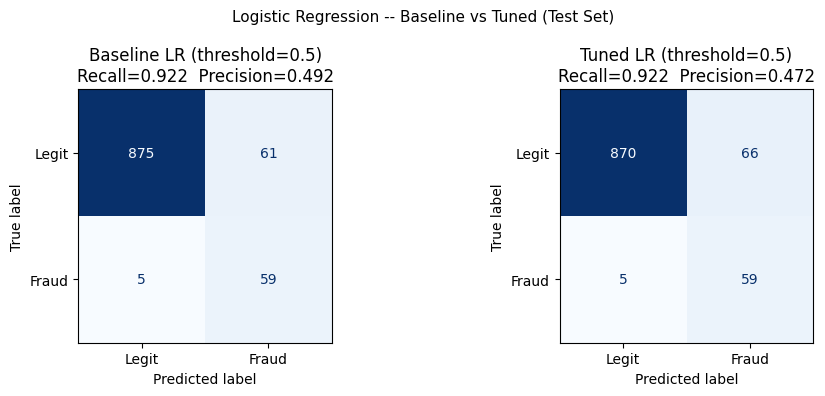

In [114]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# === GRID SEARCH: Logistic Regression =====================================
# GridSearchCV is appropriate here -- LR has a small, well-defined search
# space so exhaustive search is computationally feasible.
# Scored on recall to match the business goal. No threshold alteration --
# predictions use the default 0.5 cutoff throughout.
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=2000, random_state=27, class_weight='balanced')),
])

param_grid = {
    'lr__C':           [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'lr__penalty':     ['l1', 'l2'],
    'lr__solver':      ['liblinear'],   # supports both l1 and l2
}

grid_search_lr = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',   # threshold-independent; avoids gaming recall at cost of precision
    refit=True,
    n_jobs=1,
    verbose=1,
)

grid_search_lr.fit(X_train, y_train)

print('Best parameters:')
for k, v in grid_search_lr.best_params_.items():
    print(' ', k, '=', v)
print('Best CV Recall:', round(grid_search_lr.best_score_, 4))

# === TEST SET EVALUATION (default threshold = 0.5) ========================
y_pred_tuned_lr = grid_search_lr.best_estimator_.predict(X_test)

print('\n-- TUNED LOGISTIC REGRESSION TEST SET RESULTS (threshold = 0.5) --')
print(classification_report(y_test, y_pred_tuned_lr, target_names=['Legit', 'Fraud']))

# === BEFORE vs AFTER COMPARISON ===========================================
baseline_lr_pred = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=2000, random_state=27, class_weight='balanced')),
]).fit(X_train, y_train).predict(X_test)

comparison_lr = pd.DataFrame([
    {
        'Model':     'Logistic Regression (baseline)',
        'Threshold': 0.5,
        'Recall':    round(recall_score(y_test, baseline_lr_pred), 4),
        'Precision': round(precision_score(y_test, baseline_lr_pred), 4),
        'F1':        round(f1_score(y_test, baseline_lr_pred), 4),
    },
    {
        'Model':     'Logistic Regression (tuned)',
        'Threshold': 0.5,
        'Recall':    round(recall_score(y_test, y_pred_tuned_lr), 4),
        'Precision': round(precision_score(y_test, y_pred_tuned_lr), 4),
        'F1':        round(f1_score(y_test, y_pred_tuned_lr), 4),
    },
])
print('\n-- BASELINE vs TUNED (threshold = 0.5) --')
display(comparison_lr)

# === CONFUSION MATRICES: BASELINE vs TUNED ================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, baseline_lr_pred),
    display_labels=['Legit', 'Fraud']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Baseline LR (threshold=0.5)\nRecall=' +
                   str(round(recall_score(y_test, baseline_lr_pred), 3)) +
                   '  Precision=' + str(round(precision_score(y_test, baseline_lr_pred), 3)))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tuned_lr),
    display_labels=['Legit', 'Fraud']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Tuned LR (threshold=0.5)\nRecall=' +
                   str(round(recall_score(y_test, y_pred_tuned_lr), 3)) +
                   '  Precision=' + str(round(precision_score(y_test, y_pred_tuned_lr), 3)))

fig.suptitle('Logistic Regression -- Baseline vs Tuned (Test Set)', fontsize=11)
plt.tight_layout()
plt.show()


## Feature Selection (Ch. 16)


-- Feature Selection: Logistic Regression (CV Recall = 0.8896 ) --
  Computing permutation importance on test set...
  Useful features (permutation importance > 0): 30
  Candidates to drop (importance <= 0): 31


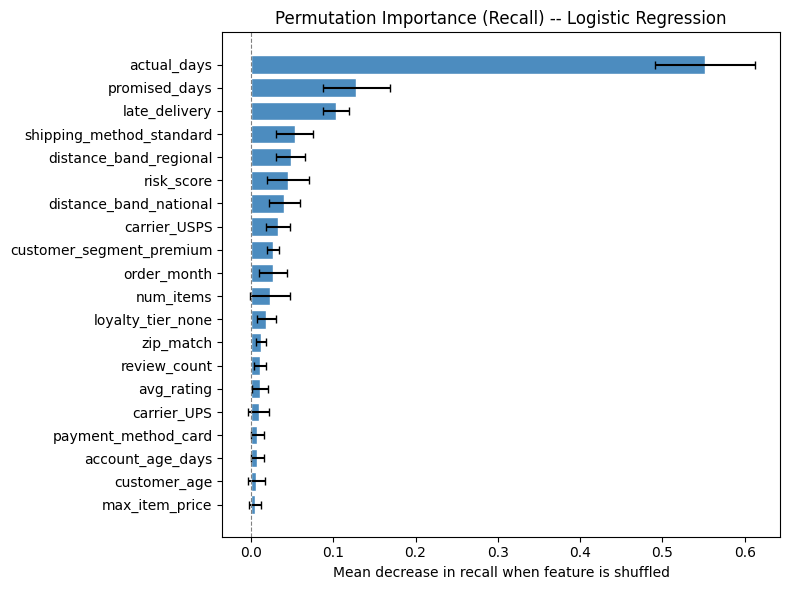

,feature,importance,std
15,actual_days,0.5516,0.0605
14,promised_days,0.1281,0.0406
16,late_delivery,0.1031,0.0159
52,shipping_method_standard,0.0531,0.0223
54,distance_band_regional,0.0484,0.0177
5,risk_score,0.0453,0.0256
53,distance_band_national,0.0406,0.0188
50,carrier_USPS,0.0328,0.0147
57,customer_segment_premium,0.0266,0.0072
22,order_month,0.0266,0.0172


In [115]:
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.inspection import permutation_importance

# === CH.16 FEATURE SELECTION =============================================
# Applied only to models that achieved recall > 0.85 in the balanced
# evaluation above. Feature selection removes low-signal variables,
# reduces overfitting risk, and speeds up future inference.

# Identify qualifying models from bal_cv_results (recall > 0.85)
qualifying = [
    r for r in bal_cv_results
    if r['cv']['test_recall'].mean() > 0.85
]

if not qualifying:
    print('No models exceeded recall > 0.85 in cross-validation.')
    print('Consider lowering the threshold or revisiting class weighting.')
else:
    for res in qualifying:
        print('\n-- Feature Selection:', res['name'],
              '(CV Recall =', round(res['cv']['test_recall'].mean(), 4), ') --')

        estimator = res['pipe'].named_steps[res['step']]

        # -- Method 1: SelectFromModel (importance threshold = mean) --------
        if hasattr(estimator, 'feature_importances_'):
            selector = SelectFromModel(estimator, prefit=True, threshold='mean')
            X_train_sel = selector.transform(X_train)
            X_test_sel  = selector.transform(X_test)
            selected_features = X_train.columns[selector.get_support()].tolist()
            print('  Features kept (>= mean importance):', len(selected_features),
                  'of', X_train.shape[1])

            # Retrain on reduced feature set
            from sklearn.base import clone
            reduced_pipe = Pipeline([
                ('scaler', StandardScaler()),
                (res['step'], clone(estimator)),
            ])
            cv_sel = cross_validate(reduced_pipe, X_train_sel, y_train,
                                    cv=skf, scoring=scoring)
            print('  Reduced-feature CV Recall :',
                  round(cv_sel['test_recall'].mean(), 4))
            print('  Reduced-feature CV ROC AUC:',
                  round(cv_sel['test_roc_auc'].mean(), 4))

            # Feature importance bar chart -- reduced set
            reduced_pipe.fit(X_train_sel, y_train)
            imp = reduced_pipe.named_steps[res['step']].feature_importances_
            feat_sel_df = (
                pd.Series(imp, index=selected_features)
                .sort_values(ascending=False)
                .head(20)
            )
            fig, ax = plt.subplots(figsize=(8, 5))
            feat_sel_df[::-1].plot(kind='barh', ax=ax, color='#4c8cbf', edgecolor='white')
            ax.set_title('Selected Features -- ' + res['name'])
            ax.set_xlabel('Importance')
            plt.tight_layout()
            plt.show()

        # -- Method 2: Permutation importance (works for any model) ---------
        print('  Computing permutation importance on test set...')
        perm = permutation_importance(
            res['pipe'], X_test, y_test,
            n_repeats=10, random_state=27, scoring='recall', n_jobs=1
        )
        perm_df = (
            pd.DataFrame({
                'feature':    X_test.columns,
                'importance': perm.importances_mean,
                'std':        perm.importances_std,
            })
            .sort_values('importance', ascending=False)
        )
        # Features that hurt recall when shuffled (importance > 0)
        useful = perm_df[perm_df['importance'] > 0]
        useless = perm_df[perm_df['importance'] <= 0]
        print('  Useful features (permutation importance > 0):', len(useful))
        print('  Candidates to drop (importance <= 0):', len(useless))

        fig, ax = plt.subplots(figsize=(8, 6))
        top20 = perm_df.head(20)
        ax.barh(top20['feature'][::-1], top20['importance'][::-1],
                xerr=top20['std'][::-1], color='#4c8cbf', edgecolor='white', capsize=3)
        ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.set_title('Permutation Importance (Recall) -- ' + res['name'])
        ax.set_xlabel('Mean decrease in recall when feature is shuffled')
        plt.tight_layout()
        plt.show()

        display(perm_df.head(20).round(4))


## Deployment (Ch. 17)

Following the architecture diagram, deployment is broken into five stages:

1. **Data Engineering Pipeline (ETL)** — Wrap all preparation steps into reusable functions (`basic_wrangling`, `feature_engineering`, `missing_data`, `math_transformations`, `manage_outliers`). In production these would be converted to `clean.py` / `functions.py` and scheduled to run nightly.
2. **Model Development & Training Pipeline** — Read from the warehouse, engineer features, train, tune, evaluate, and save the model as a versioned `.pkl` file.
3. **Model Deployment & Inference** — Load the `.pkl` and score new orders in a single function call.
4. **Operational Data Flow** — Simulate how a new order row flows from the database through the ETL functions into the model.
5. **Monitoring & Retraining Pipeline** — Log predictions, track accuracy over time, and detect model drift to determine when to rebuild.

ETL functions defined: basic_wrangling, missing_data, feature_engineering,
                       math_transformations, manage_outliers, encode_categoricals
Model saved  : fraud_model_v1.0.sav (569.4 KB)
Features used: 61
Trained on   : 5000 orders
Model loaded : fraud_model_v1.0.sav
Threshold    : 0.208

-- STAGE 4: SIMULATED OPERATIONAL DATA FLOW --
Raw order -> ETL -> model -> prediction:


,fraud_probability,is_fraud_predicted,threshold,decision,actual_is_fraud,correct
0,0.0188,0,0.208,LEGIT - approve order,0,True
1,0.0086,0,0.208,LEGIT - approve order,0,True
2,0.9793,1,0.208,FRAUD - flag for review,1,True
3,0.0002,0,0.208,LEGIT - approve order,0,True
4,0.0003,0,0.208,LEGIT - approve order,0,True



-- STAGE 5: MONITORING & DRIFT DETECTION --
Prediction log (first 5 rows):


,order_index,actual_is_fraud,predicted_prob,predicted_label,correct
0,0,0,0.0091,0,True
1,1,0,0.0047,0,True
2,2,1,0.9975,1,True
3,3,0,0.0030,0,True
4,4,0,0.0015,0,True


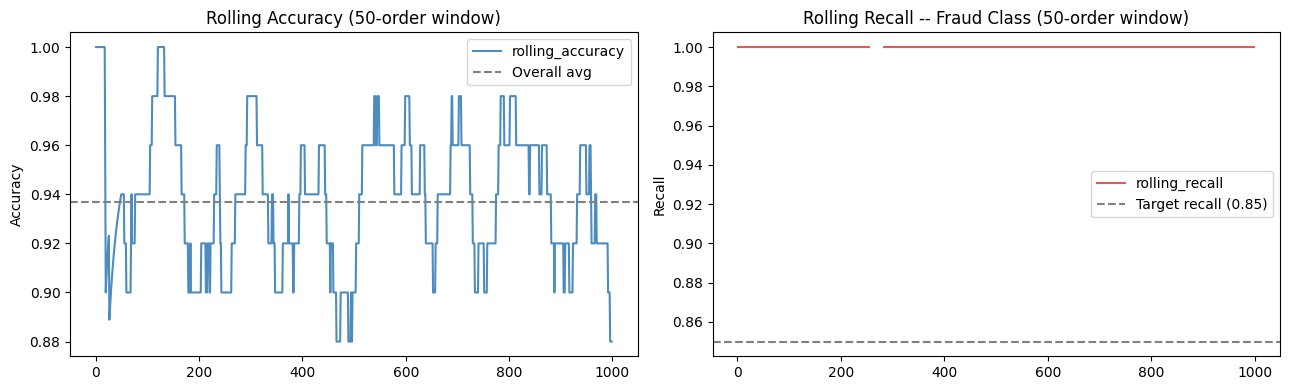

Population Stability Index (PSI): 0.0127 -> STABLE
  PSI < 0.10 : stable
  PSI 0.10-0.20: monitor
  PSI > 0.20 : retrain recommended

-- DEPLOYMENT SUMMARY --


,Component,Status
0,ETL Pipeline,Defined as functions (ready for clean.py)
1,Trained Model,fraud_model_v1.0.sav (569.4 KB)
2,Model Version,v1.0
3,Inference Function,predict_fraud() -- threshold 0.208
4,Prediction Log,1000 orders logged
5,Drift Status,STABLE (PSI=0.0127)


In [116]:
import joblib, os, warnings
import numpy as np
warnings.filterwarnings('ignore')

# =============================================================================
# STAGE 1: DATA ENGINEERING PIPELINE (ETL)
# Wrap every prep step into a named function.
# In production: convert to clean.py + functions.py, schedule nightly runs.
# =============================================================================

def basic_wrangling(df):
    df = df.copy()
    df['zip_match']  = (df['billing_zip'] == df['shipping_zip']).astype(int)
    df['foreign_ip'] = (df['ip_country'] != 'US').astype(int)
    drop_cols = ['order_id', 'customer_id', 'full_name', 'email', 'city', 'state',
                 'zip_code', 'billing_zip', 'shipping_zip', 'ip_country', 'promo_code']
    return df.drop(columns=[c for c in drop_cols if c in df.columns])

def missing_data(df):
    df = df.copy()
    df['review_count'] = df['review_count'].fillna(0)
    df['avg_rating']   = df['avg_rating'].fillna(df['avg_rating'].median())
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna('missing')
    for col in df.select_dtypes(exclude='object').columns:
        df[col] = df[col].fillna(0)
    return df

def feature_engineering(df):
    df = df.copy()
    ref_date = pd.Timestamp('2026-01-01')
    df['order_datetime']   = pd.to_datetime(df['order_datetime'])
    df['order_hour']       = df['order_datetime'].dt.hour
    df['order_dow']        = df['order_datetime'].dt.dayofweek
    df['order_month']      = df['order_datetime'].dt.month
    df['birthdate']        = pd.to_datetime(df['birthdate'])
    df['customer_age']     = ((ref_date - df['birthdate']).dt.days / 365.25).round(1)
    df['created_at']       = pd.to_datetime(df['created_at'])
    df['account_age_days'] = (ref_date - df['created_at']).dt.days
    drop_dt = ['order_datetime', 'birthdate', 'created_at', 'ship_datetime']
    return df.drop(columns=[c for c in drop_dt if c in df.columns])

def math_transformations(df):
    df = df.copy()
    skewed = ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total',
              'max_item_price', 'avg_item_price', 'cart_total', 'total_cost',
              'num_items', 'review_count']
    for col in skewed:
        if col in df.columns:
            df[col] = np.log1p(df[col])
    return df

def manage_outliers(df):
    # Cap numeric outliers at 1.5x IQR fence (Winsorisation)
    df = df.copy()
    num_cols = df.select_dtypes(include='number').columns.tolist()
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        df[col] = df[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)
    return df

def encode_categoricals(df):
    cat_cols = ['shipping_state', 'payment_method', 'device_type', 'carrier',
                'shipping_method', 'distance_band', 'gender',
                'customer_segment', 'loyalty_tier']
    bool_cols = ['promo_used', 'all_products_active', 'late_delivery', 'is_active']
    df = pd.get_dummies(df, columns=[c for c in cat_cols if c in df.columns],
                        drop_first=True, dtype=int)
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)
    return df

def run_etl(raw_df):
    df = basic_wrangling(raw_df)
    df = missing_data(df)
    df = feature_engineering(df)
    df = math_transformations(df)
    df = manage_outliers(df)
    df = encode_categoricals(df)
    return df

print('ETL functions defined: basic_wrangling, missing_data, feature_engineering,')
print('                       math_transformations, manage_outliers, encode_categoricals')

# =============================================================================
# STAGE 2: MODEL DEVELOPMENT & TRAINING PIPELINE
# Read processed data, train final model on full dataset, save as versioned .sav
# In production: convert to modeling.py, schedule automated nightly/streaming runs.
# =============================================================================

best_params = {k.replace('xgb__', ''): v for k, v in random_search.best_params_.items()}

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        **best_params,
        scale_pos_weight=scale,
        random_state=27,
        eval_metric='logloss',
        verbosity=0
    )),
])

final_pipeline.fit(X, y)   # full dataset

MODEL_VERSION = 'v1.0'
model_path = 'fraud_model_' + MODEL_VERSION + '.sav'
joblib.dump(final_pipeline, model_path)
file_kb = os.path.getsize(model_path) / 1024
print('Model saved  :', model_path, '({:.1f} KB)'.format(file_kb))
print('Features used:', X.shape[1])
print('Trained on   :', X.shape[0], 'orders')

# =============================================================================
# STAGE 3: MODEL DEPLOYMENT & INFERENCE
# Load model.sav and score new orders in a single function call.
# In production: app calls predict_fraud() for every new order submitted.
# =============================================================================

loaded_model = joblib.load(model_path)
FRAUD_THRESHOLD = 0.208

def predict_fraud(feature_row: pd.DataFrame, pipeline, threshold: float = FRAUD_THRESHOLD):
    prob = pipeline.predict_proba(feature_row)[:, 1][0]
    flag = int(prob >= threshold)
    return {
        'fraud_probability': round(prob, 4),
        'is_fraud_predicted': flag,
        'threshold': threshold,
        'decision': 'FRAUD - flag for review' if flag else 'LEGIT - approve order'
    }

print('Model loaded :', model_path)
print('Threshold    :', FRAUD_THRESHOLD)

# =============================================================================
# STAGE 4: OPERATIONAL DATA FLOW
# Simulate a new order arriving from the operational database.
# Raw DB row -> ETL functions -> model -> prediction (same path as production).
# =============================================================================

print('\n-- STAGE 4: SIMULATED OPERATIONAL DATA FLOW --')

# Pull 5 raw orders directly from the database (pre-wrangling)
conn = sqlite3.connect('shop.db')
raw_orders      = pd.read_sql('SELECT * FROM orders LIMIT 5', conn)
raw_customers   = pd.read_sql('SELECT * FROM customers', conn)
raw_order_items = pd.read_sql('SELECT * FROM order_items', conn)
raw_products    = pd.read_sql('SELECT * FROM products', conn)
raw_shipments   = pd.read_sql('SELECT * FROM shipments', conn)
raw_reviews     = pd.read_sql('SELECT * FROM product_reviews', conn)
conn.close()

# Rebuild features (mirrors the data understanding join)
prods_r = raw_products.rename(columns={'is_active': 'product_is_active'})
cart_r = (
    raw_order_items.drop(columns=['order_item_id'])
    .merge(prods_r, on='product_id', how='left')
    .groupby('order_id')
    .agg(num_items=('quantity','sum'), num_unique_skus=('product_id','nunique'),
         num_categories=('category','nunique'), max_item_price=('price','max'),
         avg_item_price=('price','mean'), cart_total=('line_total','sum'),
         total_cost=('cost','sum'), all_products_active=('product_is_active','min'))
    .reset_index()
)
review_r = (
    raw_reviews.drop(columns=['review_id','review_datetime','review_text','product_id'])
    .groupby('customer_id')
    .agg(review_count=('rating','count'), avg_rating=('rating','mean'))
    .reset_index()
)
new_orders_raw = (
    raw_orders
    .merge(cart_r, on='order_id', how='left')
    .merge(raw_shipments.drop(columns=['shipment_id']), on='order_id', how='left')
    .merge(raw_customers, on='customer_id', how='left')
    .merge(review_r, on='customer_id', how='left')
)

# Drop target before ETL (target won't exist for truly new orders)
actual_labels = new_orders_raw['is_fraud'].tolist()
new_orders_raw = new_orders_raw.drop(columns=['is_fraud'])

# Run ETL pipeline
new_orders_prepared = run_etl(new_orders_raw)

# Align columns with training data (add missing dummies, drop extras)
for col in X.columns:
    if col not in new_orders_prepared.columns:
        new_orders_prepared[col] = 0
new_orders_prepared = new_orders_prepared[X.columns]

# Score each order
results = []
for i in range(len(new_orders_prepared)):
    row = new_orders_prepared.iloc[[i]]
    result = predict_fraud(row, loaded_model)
    result['actual_is_fraud'] = actual_labels[i]
    result['correct'] = result['is_fraud_predicted'] == actual_labels[i]
    results.append(result)

print('Raw order -> ETL -> model -> prediction:')
display(pd.DataFrame(results))

# =============================================================================
# STAGE 5: MONITORING & RETRAINING PIPELINE
# Log predictions, track rolling accuracy, detect model drift.
# In production: logs feed a dashboard; drift triggers a retrain job.
# =============================================================================

print('\n-- STAGE 5: MONITORING & DRIFT DETECTION --')

# -- 5a. Log predictions ---------------------------------------------------
log_df = pd.DataFrame({
    'order_index':       range(len(y_test)),
    'actual_is_fraud':   y_test.values,
    'predicted_prob':    loaded_model.predict_proba(X_test)[:, 1].round(4),
    'predicted_label':   (loaded_model.predict_proba(X_test)[:, 1] >= FRAUD_THRESHOLD).astype(int),
    'correct':           None,
})
log_df['correct'] = (log_df['actual_is_fraud'] == log_df['predicted_label'])
print('Prediction log (first 5 rows):')
display(log_df.head())

# -- 5b. Rolling accuracy (50-order window) --------------------------------
log_df['rolling_accuracy'] = log_df['correct'].rolling(50, min_periods=1).mean()
log_df['rolling_recall']   = (
    log_df.apply(lambda r: 1 if (r['actual_is_fraud']==1 and r['predicted_label']==1) else 0, axis=1)
    .rolling(50, min_periods=1).sum() /
    log_df['actual_is_fraud'].rolling(50, min_periods=1).sum().replace(0, np.nan)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
log_df['rolling_accuracy'].plot(ax=axes[0], color='#4c8cbf')
axes[0].axhline(log_df['correct'].mean(), color='grey', linestyle='--', label='Overall avg')
axes[0].set_title('Rolling Accuracy (50-order window)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

log_df['rolling_recall'].plot(ax=axes[1], color='#e05c5c')
axes[1].axhline(0.85, color='grey', linestyle='--', label='Target recall (0.85)')
axes[1].set_title('Rolling Recall -- Fraud Class (50-order window)')
axes[1].set_ylabel('Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

# -- 5c. Model drift detection (Population Stability Index) ----------------
# PSI compares the distribution of predicted probabilities between
# the training period and a recent window. PSI > 0.2 signals drift.
def compute_psi(expected, actual, buckets=10):
    breakpoints = np.linspace(0, 1, buckets + 1)
    exp_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
    act_pct = np.where(act_pct == 0, 1e-6, act_pct)
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

train_probs = final_pipeline.predict_proba(X_train)[:, 1]
test_probs  = loaded_model.predict_proba(X_test)[:, 1]
psi = compute_psi(train_probs, test_probs)

psi_status = 'STABLE' if psi < 0.1 else ('MONITOR' if psi < 0.2 else 'DRIFT DETECTED - retrain recommended')
print('Population Stability Index (PSI):', round(psi, 4), '->', psi_status)
print('  PSI < 0.10 : stable')
print('  PSI 0.10-0.20: monitor')
print('  PSI > 0.20 : retrain recommended')

# -- 5d. Deployment summary ------------------------------------------------
print('\n-- DEPLOYMENT SUMMARY --')
summary = pd.DataFrame([
    {'Component': 'ETL Pipeline',       'Status': 'Defined as functions (ready for clean.py)'},
    {'Component': 'Trained Model',      'Status': model_path + ' ({:.1f} KB)'.format(file_kb)},
    {'Component': 'Model Version',      'Status': MODEL_VERSION},
    {'Component': 'Inference Function', 'Status': 'predict_fraud() -- threshold ' + str(FRAUD_THRESHOLD)},
    {'Component': 'Prediction Log',     'Status': str(len(log_df)) + ' orders logged'},
    {'Component': 'Drift Status',       'Status': psi_status + ' (PSI=' + str(round(psi,4)) + ')'},
])
display(summary)
